# 🏛️ Model A - Legal Information Extraction System

**Goal**: Extract structured legal information from Saudi commercial judgments

**Model Used**: AraLegal-BERT

# Model A

---
#  Part 1: Setup & Data Loading
---

##  Imports & Configuration

#  PART 1 — Setup + Data Loading

In [ ]:
import os
print(os.listdir("/kaggle/input"))

[]


In [ ]:
# PART 1 — Imports & Configuration

import os
import json
import logging
from pathlib import Path
from typing import List, Dict, Any
import numpy as np
import pandas as pd
import torch
import warnings
from sklearn.model_selection import train_test_split

In [ ]:
# ── stdlib ─────────────────────────────────────────────────────────────────────
import os
import json
import logging
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

# ── third-party ────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# HuggingFace
from datasets import Dataset, DatasetDict, ClassLabel, Sequence, Value
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
    EarlyStoppingCallback,
)

In [ ]:
from pathlib import Path

class Config:
    BASE_DIR = Path("/kaggle/input/datasets/janaalotaibi/model-a")

    BASELINE_LAWS = BASE_DIR / "01_baseline_laws.jsonl"
    SEGMENTED_CASES = BASE_DIR / "03_segmented.csv"
    ENTITY_SUMMARY = BASE_DIR / "04_entities.csv"
    TENSORS_FILE = BASE_DIR / "05_tensors.pt"

    MODEL_A_LABEL_MAP = BASE_DIR / "model_a_label_map.json"
    MODEL_A_TRAIN = BASE_DIR / "model_a_ner_bio_train.jsonl"
    MODEL_A_VAL = BASE_DIR / "model_a_ner_bio_val.jsonl"
    MODEL_A_TEST = BASE_DIR / "model_a_ner_bio_test.jsonl"

    OUTPUT_DIR = Path("/kaggle/working/outputs")
    CHECKPOINT_DIR = Path("/kaggle/working/checkpoints")
    MODEL_A_OUTPUT_DIR = OUTPUT_DIR / "model_a"

    RANDOM_SEED = 42
    MAX_LEN = 512
    MODEL_NAME = "aubmindlab/bert-base-arabertv02"

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
    MODEL_A_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
# Setup
def setup():
    Config.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    Config.CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s — %(levelname)s — %(message)s"
    )

    np.random.seed(Config.RANDOM_SEED)
    torch.manual_seed(Config.RANDOM_SEED)

    logging.info("Environment ready")


logger = logging.getLogger(__name__)

In [ ]:
# File Loaders
def load_jsonl(path: Path) -> List[Dict]:
    data = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            data.append(json.loads(line))
    return data


def load_directory_json(path: Path) -> List[Dict]:
    data = []
    for file in path.glob("*.json"):
        with open(file, "r", encoding="utf-8") as f:
            data.append(json.load(f))
    return data


def load_directory_jsonl(path: Path) -> List[Dict]:
    data = []
    for file in path.glob("*.jsonl"):
        data.extend(load_jsonl(file))
    return data

In [ ]:
# Load ALL Required Inputs
class DataLoader:

    def __init__(self):
        self.segmented_cases = []
        self.extracted_entities = []
        self.train = []
        self.val = []
        self.test = []
        self.legal_corpus = []

    def load_all(self):
        logger.info("Loading segmented cases...")
        self.segmented_cases = load_directory_jsonl(Config.SEGMENTED_CASES)

        logger.info("Loading extracted entities...")
        self.extracted_entities = load_directory_jsonl(Config.EXTRACTED_ENTITIES)

        logger.info("Loading train/val/test...")
        self.train = load_jsonl(Config.TRAIN_FILE)
        self.val = load_jsonl(Config.VAL_FILE)
        self.test = load_jsonl(Config.TEST_FILE)

        logger.info("Loading legal corpus...")
        self.legal_corpus = load_jsonl(Config.LEGAL_CORPUS)

        logger.info(f"Segmented: {len(self.segmented_cases)}")
        logger.info(f"Entities: {len(self.extracted_entities)}")
        logger.info(f"Train: {len(self.train)} | Val: {len(self.val)} | Test: {len(self.test)}")
        logger.info(f"Legal corpus: {len(self.legal_corpus)}")

        return self


In [ ]:
# Utility — Merge Case Sources
class CaseMerger:
    """
    Merge segmented cases with extracted entities using case_id
    """

    @staticmethod
    def merge(segmented: List[Dict], entities: List[Dict]) -> Dict[str, Dict]:

        entity_map = {e["case_id"]: e for e in entities}

        merged = {}

        for case in segmented:
            cid = case["case_id"]

            merged[cid] = {
                "case_id": cid,
                "segments": case.get("segments", []),
                "entities": entity_map.get(cid, {})
            }

        logging.info(f"Merged cases: {len(merged)}")

        return merged

In [ ]:
# Save Helpers
def save_jsonl(data: List[Dict], path: Path):
    with open(path, "w", encoding="utf-8") as f:
        for item in data:
            f.write(json.dumps(item, ensure_ascii=False) + "\n")


def save_json(data: Dict, path: Path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

In [ ]:
# Ready
def initialize_pipeline():
    setup()
    loader = DataLoader().load_all()
    merged_cases = CaseMerger.merge(loader.segmented_cases, loader.extracted_entities)

    return loader, merged_cases

In [ ]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    for f in files:
        print("  ", f)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/janaalotaibi
/kaggle/input/datasets/janaalotaibi/model-a
   03_segmented.csv
   model_a_ner_bio_test.jsonl
   model_a_ner_bio_train.jsonl
   05_tensors.pt
   04_entities.csv
   model_a_label_map.json
   01_baseline_laws.jsonl
   model_a_ner_bio_val.jsonl


In [ ]:
def check_model_a_files():
    files_to_check = {
        "SEGMENTED_CASES": Config.SEGMENTED_CASES,
        "ENTITY": Config.ENTITY_SUMMARY,
        "TENSORS_FILE": Config.TENSORS_FILE,
        "MODEL_A_LABEL_MAP": Config.MODEL_A_LABEL_MAP,
        "MODEL_A_TRAIN": Config.MODEL_A_TRAIN,
        "MODEL_A_VAL": Config.MODEL_A_VAL,
        "MODEL_A_TEST": Config.MODEL_A_TEST,
    }

    print("=" * 50)
    print("MODEL A FILE CHECK")
    print("=" * 50)

    for name, path in files_to_check.items():
        status = "FOUND" if path.exists() else "MISSING"
        print(f"{name:<20} -> {status} -> {path}")

check_model_a_files()

MODEL A FILE CHECK
SEGMENTED_CASES      -> FOUND -> /kaggle/input/datasets/janaalotaibi/model-a/03_segmented.csv
ENTITY               -> FOUND -> /kaggle/input/datasets/janaalotaibi/model-a/04_entities.csv
TENSORS_FILE         -> FOUND -> /kaggle/input/datasets/janaalotaibi/model-a/05_tensors.pt
MODEL_A_LABEL_MAP    -> FOUND -> /kaggle/input/datasets/janaalotaibi/model-a/model_a_label_map.json
MODEL_A_TRAIN        -> FOUND -> /kaggle/input/datasets/janaalotaibi/model-a/model_a_ner_bio_train.jsonl
MODEL_A_VAL          -> FOUND -> /kaggle/input/datasets/janaalotaibi/model-a/model_a_ner_bio_val.jsonl
MODEL_A_TEST         -> FOUND -> /kaggle/input/datasets/janaalotaibi/model-a/model_a_ner_bio_test.jsonl


In [ ]:
with open(Config.MODEL_A_LABEL_MAP, "r", encoding="utf-8") as f:
    label_map = json.load(f)

print("Labels:")
print(label_map["labels"])
print("\nNumber of labels:", len(label_map["labels"]))

Labels:
['O', 'B-اسم_نظام', 'B-تاريخ', 'B-رقم_قضية', 'B-مبلغ_مالي', 'B-محكمة', 'B-مرجع_قانوني', 'I-اسم_نظام', 'I-تاريخ', 'I-رقم_قضية', 'I-مبلغ_مالي', 'I-محكمة', 'I-مرجع_قانوني']

Number of labels: 13


In [ ]:
def read_jsonl_sample(path, n=2):
    samples = []
    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            samples.append(json.loads(line))
            if i + 1 >= n:
                break
    return samples

samples = read_jsonl_sample(Config.MODEL_A_TRAIN, n=2)

for i, s in enumerate(samples, 1):
    print(f"\n===== SAMPLE {i} =====")
    print("case_id:", s.get("case_id"))
    print("segment_id:", s.get("segment_id"))
    print("tokens[:30]:", s.get("tokens", [])[:30])
    print("bio_tags[:30]:", s.get("bio_tags", [])[:30])


===== SAMPLE 1 =====
case_id: Gtwi21o7wSn-SSueeVqtaIZlTMnt0N4WymYtp1q4bc1OFpnzGle6ZkJWgSt_DSJ2
segment_id: d5ea6e68-18de-4285-a139-cddd4c599f0b
tokens[:30]: ['[CLS]', 'الحمد', 'لله', 'والصلاة', 'والسلام', 'على', 'رسول', 'الله', '،', 'اما', 'بعد', ':', 'فل', '##دى', 'الدائرة', 'التاسعة', 'عشرة', 'وبناء', 'على', 'القضية', 'رقم', '46', '##30', '##58', '##50', '##68', 'لعام', '144', '##6', '##ه']
bio_tags[:30]: ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-محكمة', 'I-محكمة', 'I-محكمة', 'I-محكمة', 'I-محكمة', 'B-رقم_قضية', 'B-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'O']

===== SAMPLE 2 =====
case_id: Gtwi21o7wSn-SSueeVqtaIZlTMnt0N4WymYtp1q4bc1OFpnzGle6ZkJWgSt_DSJ2
segment_id: bd406c93-2a21-49df-badb-5bf84c700616
tokens[:30]: ['[CLS]', 'الحمد', 'لله', 'والصلاة', 'والسلام', 'على', 'رسول', 'الله', '،', 'اما', 'بعد', ':', 'فل', '##دى', 'الدائرة', 'التاسعة', 'عشرة', 'وبناء', 'على', 'الق

In [ ]:
from datasets import Dataset
import json

def load_jsonl_to_dataset(file_path):
    data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            data.append(json.loads(line))
    return Dataset.from_list(data)

In [ ]:
train_ds = load_jsonl_to_dataset(Config.MODEL_A_TRAIN)

In [ ]:
def find_bio_errors(dataset):
    errors = []

    for i, example in enumerate(dataset):
        tags = example["bio_tags"]

        for j in range(1, len(tags)):
            prev_tag = tags[j-1]
            curr_tag = tags[j]

            # لو الاثنين B لنفس الكيان → خطأ
            if prev_tag.startswith("B-") and curr_tag.startswith("B-"):
                if prev_tag[2:] == curr_tag[2:]:
                    errors.append((i, j, prev_tag, curr_tag))

    return errors


errors = find_bio_errors(train_ds)

print("Number of BIO errors:", len(errors))
print("Sample errors:", errors[:10])

Number of BIO errors: 10160
Sample errors: [(0, 20, 'B-رقم_قضية', 'B-رقم_قضية'), (1, 20, 'B-رقم_قضية', 'B-رقم_قضية'), (39, 133, 'B-رقم_قضية', 'B-رقم_قضية'), (51, 19, 'B-رقم_قضية', 'B-رقم_قضية'), (52, 19, 'B-رقم_قضية', 'B-رقم_قضية'), (63, 127, 'B-رقم_قضية', 'B-رقم_قضية'), (92, 19, 'B-رقم_قضية', 'B-رقم_قضية'), (93, 19, 'B-رقم_قضية', 'B-رقم_قضية'), (102, 34, 'B-رقم_قضية', 'B-رقم_قضية'), (111, 18, 'B-رقم_قضية', 'B-رقم_قضية')]


In [ ]:
def fix_repeated_B_tags(dataset):
    fixed_data = []
    fixed_count = 0

    for example in dataset:
        example = dict(example)
        tags = list(example["bio_tags"])

        for i in range(1, len(tags)):
            prev_tag = tags[i - 1]
            curr_tag = tags[i]

            if prev_tag.startswith(("B-", "I-")) and curr_tag.startswith("B-"):
                prev_label = prev_tag[2:]
                curr_label = curr_tag[2:]

                if prev_label == curr_label:
                    tags[i] = "I-" + curr_label
                    fixed_count += 1

        example["bio_tags"] = tags
        fixed_data.append(example)

    return fixed_data, fixed_count


fixed_train_data, fixed_count = fix_repeated_B_tags(train_ds)

print("Fixed count:", fixed_count)

Fixed count: 15778


In [ ]:
fixed_train_data, fixed_count = fix_repeated_B_tags(train_ds)
print("Fixed count:", fixed_count)

Fixed count: 15778


In [ ]:
from datasets import Dataset

train_ds_fixed = Dataset.from_list(fixed_train_data)

In [ ]:
errors_after = find_bio_errors(train_ds_fixed)

print("BIO errors before:", len(errors))
print("Fixed count:", fixed_count)
print("BIO errors after:", len(errors_after))
print("Sample errors after:", errors_after[:10])

BIO errors before: 10160
Fixed count: 15778
BIO errors after: 0
Sample errors after: []


In [ ]:
val_ds = load_jsonl_to_dataset(Config.MODEL_A_VAL)
test_ds = load_jsonl_to_dataset(Config.MODEL_A_TEST)

In [ ]:
fixed_val_data, val_fixed_count = fix_repeated_B_tags(val_ds)
fixed_test_data, test_fixed_count = fix_repeated_B_tags(test_ds)

In [ ]:
from datasets import Dataset

val_ds_fixed = Dataset.from_list(fixed_val_data)
test_ds_fixed = Dataset.from_list(fixed_test_data)

In [ ]:
print("Val errors after:", len(find_bio_errors(val_ds_fixed)))
print("Test errors after:", len(find_bio_errors(test_ds_fixed)))

Val errors after: 0
Test errors after: 0


In [ ]:
def find_I_without_B(dataset):
    errors = []

    for i, example in enumerate(dataset):
        tags = example["bio_tags"]

        for j in range(len(tags)):
            tag = tags[j]

            if tag.startswith("I-"):
                label = tag[2:]

                if j == 0:
                    errors.append((i, j, tag, "START"))
                else:
                    prev = tags[j-1]

                    if not (prev == "B-" + label or prev == "I-" + label):
                        errors.append((i, j, tag, prev))

    return errors


for name, ds in [
    ("train", train_ds_fixed),
    ("val", val_ds_fixed),
    ("test", test_ds_fixed)
]:
    errs = find_I_without_B(ds)
    print(name, "I-without-B errors:", len(errs))
    print("sample:", errs[:5])

train I-without-B errors: 2560
sample: [(10, 92, 'I-محكمة', 'I-اسم_نظام'), (54, 416, 'I-مرجع_قانوني', 'I-اسم_نظام'), (57, 125, 'I-مرجع_قانوني', 'I-اسم_نظام'), (57, 210, 'I-محكمة', 'I-اسم_نظام'), (62, 169, 'I-محكمة', 'I-اسم_نظام')]
val I-without-B errors: 528
sample: [(23, 229, 'I-مرجع_قانوني', 'I-اسم_نظام'), (65, 16, 'I-مرجع_قانوني', 'I-اسم_نظام'), (83, 19, 'I-مرجع_قانوني', 'I-اسم_نظام'), (89, 348, 'I-مرجع_قانوني', 'I-اسم_نظام'), (89, 431, 'I-مرجع_قانوني', 'I-اسم_نظام')]
test I-without-B errors: 558
sample: [(28, 365, 'I-محكمة', 'I-اسم_نظام'), (33, 48, 'I-مرجع_قانوني', 'I-اسم_نظام'), (35, 328, 'I-محكمة', 'I-اسم_نظام'), (35, 450, 'I-محكمة', 'I-اسم_نظام'), (36, 170, 'I-محكمة', 'I-اسم_نظام')]


In [ ]:
def fix_I_without_B(dataset):
    fixed_data = []
    fixed_count = 0

    for example in dataset:
        example = dict(example)
        tags = list(example["bio_tags"])

        for i in range(len(tags)):
            tag = tags[i]

            if tag.startswith("I-"):
                label = tag[2:]

                if i == 0:
                    tags[i] = "B-" + label
                    fixed_count += 1
                else:
                    prev = tags[i - 1]

                    if not (prev == "B-" + label or prev == "I-" + label):
                        tags[i] = "B-" + label
                        fixed_count += 1

        example["bio_tags"] = tags
        fixed_data.append(example)

    return Dataset.from_list(fixed_data), fixed_count

In [ ]:
train_ds_final, train_i_fixed = fix_I_without_B(train_ds_fixed)
val_ds_final, val_i_fixed = fix_I_without_B(val_ds_fixed)
test_ds_final, test_i_fixed = fix_I_without_B(test_ds_fixed)

print("Train I fixed:", train_i_fixed)
print("Val I fixed:", val_i_fixed)
print("Test I fixed:", test_i_fixed)

Train I fixed: 2560
Val I fixed: 528
Test I fixed: 558


In [ ]:
print("Train repeated B:", len(find_bio_errors(train_ds_final)))
print("Val repeated B:", len(find_bio_errors(val_ds_final)))
print("Test repeated B:", len(find_bio_errors(test_ds_final)))

print("Train I errors:", len(find_I_without_B(train_ds_final)))
print("Val I errors:", len(find_I_without_B(val_ds_final)))
print("Test I errors:", len(find_I_without_B(test_ds_final)))

Train repeated B: 0
Val repeated B: 0
Test repeated B: 0
Train I errors: 0
Val I errors: 0
Test I errors: 0


In [ ]:
from collections import Counter
import json

def label_distribution(path, max_records=2000):
    counter = Counter()
    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            rec = json.loads(line)
            counter.update(rec.get("bio_tags", []))
            if i + 1 >= max_records:
                break
    return counter

dist = label_distribution(Config.MODEL_A_TRAIN, max_records=2000)

for label, count in dist.most_common():
    print(label, count)

O 206169
I-محكمة 17048
I-اسم_نظام 3592
I-تاريخ 3218
I-مرجع_قانوني 2031
I-رقم_قضية 1784
B-محكمة 1499
B-اسم_نظام 714
B-تاريخ 569
I-مبلغ_مالي 535
B-رقم_قضية 410
B-مرجع_قانوني 340
B-مبلغ_مالي 205


In [ ]:
import json

def validate_bio_file(path, max_check=500):
    bad = 0
    checked = 0

    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            rec = json.loads(line)
            tokens = rec.get("tokens", [])
            tags = rec.get("bio_tags", [])

            if len(tokens) != len(tags):
                bad += 1
                print(f"Mismatch in record {i}: tokens={len(tokens)}, tags={len(tags)}")

            checked += 1
            if checked >= max_check:
                break

    print(f"Checked records: {checked}")
    print(f"Mismatches: {bad}")

---
#  Part 2: Data Processing & Cleaning
---

##  Load Data & Fix BIO Tagging Errors

In [ ]:
validate_bio_file(Config.MODEL_A_TRAIN)
validate_bio_file(Config.MODEL_A_VAL)
validate_bio_file(Config.MODEL_A_TEST)

Checked records: 500
Mismatches: 0
Checked records: 500
Mismatches: 0
Checked records: 500
Mismatches: 0


# MODEL A — READER / EXTRACTOR  

> **Goal**: Extract structured legal information from Saudi commercial judgments and legal texts.


> **Use**: *AraLegal-BERT* otherwise create a training-ready transformer-based extraction pipeline with a working baseline




# 1. Environment Setup & Dependency Installation

In [ ]:
import transformers, datasets, accelerate
print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("accelerate:", accelerate.__version__)

transformers: 5.0.0
datasets: 4.8.3
accelerate: 1.12.0


In [ ]:
!pip install -q transformers datasets seqeval evaluate accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.4 MB/s eta 0:00:00


In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer
)
import evaluate

In [ ]:
# Install required libraries
!pip install -q transformers[torch] datasets seqeval sentencepiece
!pip install -q pandas numpy

# 2. Google Drive Integration

In [ ]:
from pathlib import Path

# 📂 مسارات الحفظ في Kaggle
CHECKPOINT_DIR = Path("/kaggle/working/model_a/checkpoints")
FINAL_MODEL_DIR = Path("/kaggle/working/model_a/final_model")

# إنشاء الفولدرات
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
FINAL_MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Paths ready:")
print("Checkpoints:", CHECKPOINT_DIR)
print("Final model:", FINAL_MODEL_DIR)

✅ Paths ready:
Checkpoints: /kaggle/working/model_a/checkpoints
Final model: /kaggle/working/model_a/final_model


In [ ]:
from pathlib import Path

# Version name
RUN_NAME = "model_a_v3"

# 📂 Base (مكان الحفظ في Kaggle)
BASE_DIR = Path("/kaggle/working/TMSJfinal")

# Paths
CHECKPOINT_DIR = BASE_DIR / RUN_NAME / "checkpoints"
FINAL_MODEL_DIR = BASE_DIR / RUN_NAME / "final_model"

# Create folders
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
FINAL_MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Paths ready:")
print("Run name:", RUN_NAME)
print("Checkpoints:", CHECKPOINT_DIR)
print("Final model:", FINAL_MODEL_DIR)

✅ Paths ready:
Run name: model_a_v3
Checkpoints: /kaggle/working/TMSJfinal/model_a_v3/checkpoints
Final model: /kaggle/working/TMSJfinal/model_a_v3/final_model


# 3. Data Loading & Preprocessing

In [ ]:
from pathlib import Path

class Config:
    # 📂 مكان البيانات (Kaggle input)
    BASE_DIR = Path("/kaggle/input/datasets/janaalotaibi/model-a")

    MODEL_A_LABEL_MAP = BASE_DIR / "model_a_label_map.json"
    MODEL_A_TRAIN = BASE_DIR / "model_a_ner_bio_train.jsonl"
    MODEL_A_VAL   = BASE_DIR / "model_a_ner_bio_val.jsonl"
    MODEL_A_TEST  = BASE_DIR / "model_a_ner_bio_test.jsonl"

    # 💾 مكان الحفظ (Kaggle working)
    OUTPUT_DIR = Path("/kaggle/working/model_a_training_outputs")

    MODEL_NAME = "aubmindlab/bert-base-arabertv02"
    MAX_LEN = 512
    RANDOM_SEED = 42

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
print(Config.MODEL_A_TRAIN.exists())
print(Config.MODEL_A_VAL.exists())
print(Config.MODEL_A_TEST.exists())
print(Config.MODEL_A_LABEL_MAP.exists())

True
True
True
True


In [ ]:
def load_jsonl(path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            records.append(json.loads(line))
    return records

train_records = load_jsonl(Config.MODEL_A_TRAIN)
val_records = load_jsonl(Config.MODEL_A_VAL)
test_records = load_jsonl(Config.MODEL_A_TEST)

print("Train:", len(train_records))
print("Val:", len(val_records))
print("Test:", len(test_records))

Train: 62091
Val: 13364
Test: 13364


In [ ]:
train_dataset = Dataset.from_list(train_records)
val_dataset = Dataset.from_list(val_records)
test_dataset = Dataset.from_list(test_records)

In [ ]:
print(train_dataset.column_names)
print(val_dataset.column_names)
print(test_dataset.column_names)

['tokens', 'bio_tags', 'input_ids', 'attention_mask', 'case_id', 'segment_id']
['tokens', 'bio_tags', 'input_ids', 'attention_mask', 'case_id', 'segment_id']
['tokens', 'bio_tags', 'input_ids', 'attention_mask', 'case_id', 'segment_id']


# 4. Tokenization & Subword Label Alignment

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(Config.MODEL_NAME)

print("✅ Tokenizer loaded")

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✅ Tokenizer loaded


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(Config.MODEL_NAME)

In [ ]:
keep_cols = ["input_ids", "attention_mask", "labels"]

train_dataset = train_dataset.remove_columns([c for c in train_dataset.column_names if c not in keep_cols])
val_dataset = val_dataset.remove_columns([c for c in val_dataset.column_names if c not in keep_cols])
test_dataset = test_dataset.remove_columns([c for c in test_dataset.column_names if c not in keep_cols])

print(train_dataset)
print(val_dataset)
print(test_dataset)

Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 62091
})
Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 13364
})
Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 13364
})


# 5. Load Pretrained Model

In [ ]:


with open(Config.MODEL_A_LABEL_MAP, "r", encoding="utf-8") as f:
    label_map_data = json.load(f)

label_list = label_map_data["labels"]
label2id = label_map_data["label2id"]
id2label = {v: k for k, v in label2id.items()}

print("Labels:", label_list)
print("Number of labels:", len(label_list))
print("label2id:", label2id)

Labels: ['O', 'B-اسم_نظام', 'B-تاريخ', 'B-رقم_قضية', 'B-مبلغ_مالي', 'B-محكمة', 'B-مرجع_قانوني', 'I-اسم_نظام', 'I-تاريخ', 'I-رقم_قضية', 'I-مبلغ_مالي', 'I-محكمة', 'I-مرجع_قانوني']
Number of labels: 13
label2id: {'O': 0, 'B-اسم_نظام': 1, 'B-تاريخ': 2, 'B-رقم_قضية': 3, 'B-مبلغ_مالي': 4, 'B-محكمة': 5, 'B-مرجع_قانوني': 6, 'I-اسم_نظام': 7, 'I-تاريخ': 8, 'I-رقم_قضية': 9, 'I-مبلغ_مالي': 10, 'I-محكمة': 11, 'I-مرجع_قانوني': 12}


In [ ]:
from transformers import AutoModelForTokenClassification

model = AutoModelForTokenClassification.from_pretrained(
    Config.MODEL_NAME,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

print("✅ Model loaded")

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you

✅ Model loaded


In [ ]:
from transformers import AutoModelForTokenClassification

model = AutoModelForTokenClassification.from_pretrained(
    Config.MODEL_NAME,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

print("✅ Model loaded")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you

✅ Model loaded


# 6. Data Collator

In [ ]:
from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

print("✅ Data collator ready")

✅ Data collator ready


# 7. Define Metrics

In [ ]:
import numpy as np
import evaluate

seqeval = evaluate.load("seqeval")

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_predictions = []
    true_labels = []

    for pred, lab in zip(predictions, labels):
        current_preds = []
        current_labels = []
        for p_i, l_i in zip(pred, lab):
            if l_i != -100:
                current_preds.append(label_list[p_i])
                current_labels.append(label_list[l_i])
        true_predictions.append(current_preds)
        true_labels.append(current_labels)

    results = seqeval.compute(predictions=true_predictions, references=true_labels)

    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

print("✅ Metrics ready")

✅ Metrics ready


# 8. Training Arguments

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir=str(CHECKPOINT_DIR),
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    seed=Config.RANDOM_SEED,
    report_to="none"
)

print("✅ Training arguments ready")

✅ Training arguments ready


# 9. Initialize Trainer

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("✅ Trainer ready")

✅ Trainer ready


In [ ]:
print(train_dataset[0])

{'input_ids': [2, 6620, 3074, 36829, 6404, 323, 9098, 647, 103, 2735, 446, 31, 1985, 803, 4982, 6347, 2356, 6251, 323, 2521, 2245, 5701, 6069, 34489, 3520, 20659, 4967, 33468, 214, 195, 1, 31, 14, 20, 20, 20, 15, 1, 869, 31, 14, 20, 20, 20, 15, 3], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [ ]:
print(train_ds_fixed[0]["bio_tags"][:30])

['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-محكمة', 'I-محكمة', 'I-محكمة', 'I-محكمة', 'I-محكمة', 'B-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'O']


# 10. Start Training

In [ ]:
import json
from datasets import Dataset

def load_jsonl(path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            records.append(json.loads(line))
    return records

train_records = load_jsonl(Config.MODEL_A_TRAIN)
val_records = load_jsonl(Config.MODEL_A_VAL)
test_records = load_jsonl(Config.MODEL_A_TEST)

train_dataset = Dataset.from_list(train_records)
val_dataset = Dataset.from_list(val_records)
test_dataset = Dataset.from_list(test_records)

print(train_dataset.column_names)
print(val_dataset.column_names)
print(test_dataset.column_names)

['tokens', 'bio_tags', 'input_ids', 'attention_mask', 'case_id', 'segment_id']
['tokens', 'bio_tags', 'input_ids', 'attention_mask', 'case_id', 'segment_id']
['tokens', 'bio_tags', 'input_ids', 'attention_mask', 'case_id', 'segment_id']


---
#  Part 3: Model Building & Training
---

##  Training Environment Setup

In [ ]:
with open(Config.MODEL_A_LABEL_MAP, "r", encoding="utf-8") as f:
    label_map_data = json.load(f)

label_list = label_map_data["labels"]
label2id = label_map_data["label2id"]
id2label = {v: k for k, v in label2id.items()}

print(label_list)

['O', 'B-اسم_نظام', 'B-تاريخ', 'B-رقم_قضية', 'B-مبلغ_مالي', 'B-محكمة', 'B-مرجع_قانوني', 'I-اسم_نظام', 'I-تاريخ', 'I-رقم_قضية', 'I-مبلغ_مالي', 'I-محكمة', 'I-مرجع_قانوني']


In [ ]:
def encode_labels(example):
    example["labels"] = [label2id[tag] for tag in example["bio_tags"]]
    return example

train_dataset = train_dataset.map(encode_labels)
val_dataset = val_dataset.map(encode_labels)
test_dataset = test_dataset.map(encode_labels)

print(train_dataset.column_names)
print(train_dataset[0])

Map:   0%|          | 0/62091 [00:00<?, ? examples/s]

Map:   0%|          | 0/13364 [00:00<?, ? examples/s]

Map:   0%|          | 0/13364 [00:00<?, ? examples/s]

['tokens', 'bio_tags', 'input_ids', 'attention_mask', 'case_id', 'segment_id', 'labels']
{'tokens': ['[CLS]', 'الحمد', 'لله', 'والصلاة', 'والسلام', 'على', 'رسول', 'الله', '،', 'اما', 'بعد', ':', 'فل', '##دى', 'الدائرة', 'التاسعة', 'عشرة', 'وبناء', 'على', 'القضية', 'رقم', '46', '##30', '##58', '##50', '##68', 'لعام', '144', '##6', '##ه', '[UNK]', ':', '(', '.', '.', '.', ')', '[UNK]', 'عليه', ':', '(', '.', '.', '.', ')', '[SEP]'], 'bio_tags': ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-محكمة', 'I-محكمة', 'I-محكمة', 'I-محكمة', 'I-محكمة', 'B-رقم_قضية', 'B-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O'], 'input_ids': [2, 6620, 3074, 36829, 6404, 323, 9098, 647, 103, 2735, 446, 31, 1985, 803, 4982, 6347, 2356, 6251, 323, 2521, 2245, 5701, 6069, 34489, 3520, 20659, 4967, 33468, 214, 195, 1, 31, 14, 20, 2

In [ ]:
def convert_tags_to_ids(example):
    example["labels"] = [label2id[tag] for tag in example["bio_tags"]]
    return example

train_dataset = train_dataset.map(convert_tags_to_ids)

print(train_dataset[0]["bio_tags"][:30])
print(train_dataset[0]["labels"][:30])

Map:   0%|          | 0/62091 [00:00<?, ? examples/s]

['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-محكمة', 'I-محكمة', 'I-محكمة', 'I-محكمة', 'I-محكمة', 'B-رقم_قضية', 'B-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'O']
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 11, 11, 11, 11, 3, 3, 9, 9, 9, 9, 9, 9, 9, 9, 0]


In [ ]:
# Fix repeated B-tags directly on current train_dataset
fixed_train_data, fixed_count = fix_repeated_B_tags(train_dataset)

from datasets import Dataset
train_dataset = Dataset.from_list(fixed_train_data)

print("Fixed count:", fixed_count)
print(train_dataset[0]["bio_tags"][:30])

Fixed count: 15778
['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-محكمة', 'I-محكمة', 'I-محكمة', 'I-محكمة', 'I-محكمة', 'B-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'O']


In [ ]:
def convert_tags_to_ids(example):
    example["labels"] = [label2id[tag] for tag in example["bio_tags"]]
    return example

train_dataset = train_dataset.map(convert_tags_to_ids)

print(train_dataset[0]["bio_tags"][:30])
print(train_dataset[0]["labels"][:30])

Map:   0%|          | 0/62091 [00:00<?, ? examples/s]

['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-محكمة', 'I-محكمة', 'I-محكمة', 'I-محكمة', 'I-محكمة', 'B-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'O']
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 11, 11, 11, 11, 3, 9, 9, 9, 9, 9, 9, 9, 9, 9, 0]


In [ ]:
fixed_val_data, val_fixed_count = fix_repeated_B_tags(val_dataset)
val_dataset = Dataset.from_list(fixed_val_data)

fixed_test_data, test_fixed_count = fix_repeated_B_tags(test_dataset)
test_dataset = Dataset.from_list(fixed_test_data)

print("Val fixed count:", val_fixed_count)
print("Test fixed count:", test_fixed_count)

Val fixed count: 3470
Test fixed count: 3386


In [ ]:
val_dataset = val_dataset.map(convert_tags_to_ids)
test_dataset = test_dataset.map(convert_tags_to_ids)

print(val_dataset[0]["bio_tags"][:30])
print(val_dataset[0]["labels"][:30])

Map:   0%|          | 0/13364 [00:00<?, ? examples/s]

Map:   0%|          | 0/13364 [00:00<?, ? examples/s]

['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-محكمة', 'I-محكمة', 'I-محكمة', 'I-محكمة', 'I-محكمة', 'B-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'O', 'O']
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 11, 11, 11, 11, 3, 9, 9, 9, 9, 9, 9, 9, 9, 9, 0, 0]


In [ ]:
print("Train BIO errors:", len(find_bio_errors(train_dataset)))
print("Val BIO errors:", len(find_bio_errors(val_dataset)))
print("Test BIO errors:", len(find_bio_errors(test_dataset)))

Train BIO errors: 0
Val BIO errors: 0
Test BIO errors: 0


In [ ]:
raw_datasets = DatasetDict({
    "train": train_dataset,
    "validation": val_dataset,
    "test": test_dataset
})

In [ ]:
from datasets import DatasetDict

raw_datasets = DatasetDict({
    "train": train_dataset,
    "validation": val_dataset,
    "test": test_dataset
})

print(raw_datasets)

DatasetDict({
    train: Dataset({
        features: ['tokens', 'bio_tags', 'input_ids', 'attention_mask', 'case_id', 'segment_id', 'labels'],
        num_rows: 62091
    })
    validation: Dataset({
        features: ['tokens', 'bio_tags', 'input_ids', 'attention_mask', 'case_id', 'segment_id', 'labels'],
        num_rows: 13364
    })
    test: Dataset({
        features: ['tokens', 'bio_tags', 'input_ids', 'attention_mask', 'case_id', 'segment_id', 'labels'],
        num_rows: 13364
    })
})


In [ ]:
print(raw_datasets["train"][0].keys())

dict_keys(['tokens', 'bio_tags', 'input_ids', 'attention_mask', 'case_id', 'segment_id', 'labels'])


In [ ]:
tokenized_datasets = raw_datasets.remove_columns(
    ["tokens", "bio_tags", "case_id", "segment_id"]
)

print(tokenized_datasets)

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 62091
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 13364
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 13364
    })
})


In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("✅ Trainer rebuilt successfully")

✅ Trainer rebuilt successfully


In [ ]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.106523,0.049508,0.845667,0.936476,0.888758,0.986610
2,0.044057,0.043497,0.879054,0.965935,0.920449,0.987929
3,0.034752,0.045286,0.902245,0.952035,0.926472,0.988591


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=11643, training_loss=0.06177735486350436, metrics={'train_runtime': 9915.3901, 'train_samples_per_second': 18.786, 'train_steps_per_second': 1.174, 'total_flos': 4.165679695400477e+16, 'train_loss': 0.06177735486350436, 'epoch': 3.0})

In [ ]:
trainer.save_model(FINAL_MODEL_DIR)
tokenizer.save_pretrained(FINAL_MODEL_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/kaggle/working/model_a_v3/final_model/tokenizer_config.json',
 '/kaggle/working/model_a_v3/final_model/tokenizer.json')

In [ ]:
import os
print(os.listdir(FINAL_MODEL_DIR))

['tokenizer.json', 'model.safetensors', 'config.json', 'training_args.bin', 'tokenizer_config.json']


In [ ]:
import shutil

shutil.make_archive(
    str(FINAL_MODEL_DIR),
    'zip',
    str(FINAL_MODEL_DIR)
)

'/kaggle/working/model_a_v3/final_model.zip'

In [ ]:
import shutil

shutil.copy(
    "/kaggle/working/model_a_v3/final_model.zip",
    "/kaggle/working/final_model.zip"
)

'/kaggle/working/final_model.zip'

In [ ]:
from IPython.display import FileLink
FileLink('/kaggle/working/final_model.zip')

/kaggle/working/final_model.zip

In [ ]:
import os
print(os.path.exists('/kaggle/working/model_a_v3/final_model.zip'))

True


In [ ]:
import os

print(os.listdir(FINAL_MODEL_DIR))

['tokenizer.json', 'model.safetensors', 'config.json', 'training_args.bin', 'tokenizer_config.json']


In [ ]:
trainer.save_model(str(FINAL_MODEL_DIR))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
print(os.listdir(FINAL_MODEL_DIR))

['tokenizer.json', 'model.safetensors', 'config.json', 'training_args.bin', 'tokenizer_config.json']


In [ ]:
import os
print(os.listdir(CHECKPOINT_DIR))

['checkpoint-7762', 'checkpoint-11643']


In [ ]:
print(FINAL_MODEL_DIR)

/kaggle/working/model_a_v3/final_model


In [ ]:
import shutil

zip_path = "/kaggle/working/model_a_final.zip"

shutil.make_archive(
    base_name=zip_path.replace(".zip", ""),
    format="zip",
    root_dir=str(FINAL_MODEL_DIR)
)

print("✅ Model zipped at:", zip_path)

✅ Model zipped at: /kaggle/working/model_a_final.zip


# Extracting and Loading Training from ZIP File

In [ ]:
import shutil

shutil.unpack_archive(
    "/kaggle/working/model_a_final.zip",
    "/kaggle/working/model_a_loaded"
)

In [ ]:
from transformers import AutoModelForTokenClassification, AutoTokenizer

model_path = "/kaggle/working/model_a_loaded"

model = AutoModelForTokenClassification.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(model_path)

print("✅ Model loaded successfully")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Model loaded successfully


# 11. Evaluate Model

In [ ]:
val_results = trainer.evaluate(val_dataset)
test_results = trainer.evaluate(test_dataset)

print("Validation Results:", val_results)
print("Test Results:", test_results)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Validation Results: {'eval_loss': 0.04528595879673958, 'eval_precision': 0.9022452911800558, 'eval_recall': 0.9520351852620224, 'eval_f1': 0.926471775821691, 'eval_accuracy': 0.9885909180970656, 'eval_runtime': 233.8088, 'eval_samples_per_second': 57.158, 'eval_steps_per_second': 3.576, 'epoch': 3.0}
Test Results: {'eval_loss': 0.04139390587806702, 'eval_precision': 0.9145509362107268, 'eval_recall': 0.9516615067079464, 'eval_f1': 0.9327372403050594, 'eval_accuracy': 0.9898254779657684, 'eval_runtime': 236.9374, 'eval_samples_per_second': 56.403, 'eval_steps_per_second': 3.528, 'epoch': 3.0}


In [ ]:
logs = trainer.state.log_history

In [ ]:
train_loss = []
eval_loss = []
epochs = []

for log in logs:
    if "loss" in log and "epoch" in log:
        train_loss.append(log["loss"])
    if "eval_loss" in log:
        eval_loss.append(log["eval_loss"])
        epochs.append(log["epoch"])

**Extract Train and Validation Logs Correctly**

In [ ]:
train_epochs = []
train_loss = []

eval_epochs = []
eval_loss = []
eval_f1 = []

for log in trainer.state.log_history:
    if "loss" in log and "epoch" in log and "eval_loss" not in log:
        train_epochs.append(log["epoch"])
        train_loss.append(log["loss"])

    if "eval_loss" in log and "epoch" in log:
        eval_epochs.append(log["epoch"])
        eval_loss.append(log["eval_loss"])

    if "eval_f1" in log and "epoch" in log:
        eval_f1.append(log["eval_f1"])

**Plot Loss Curves**

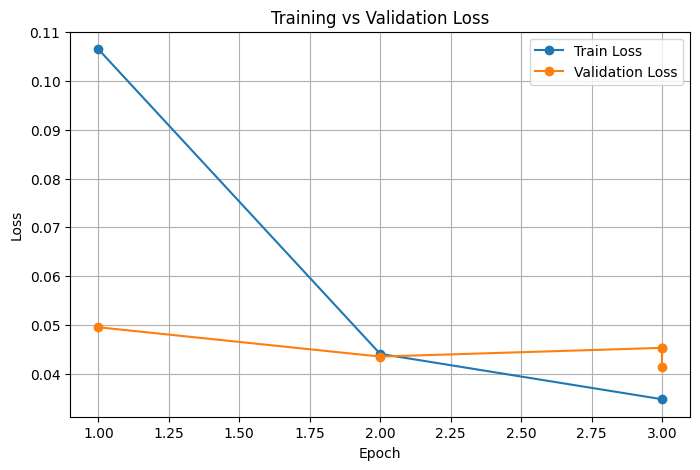

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_epochs, train_loss, marker="o", label="Train Loss")
plt.plot(eval_epochs, eval_loss, marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

**Plot F1 Curve**

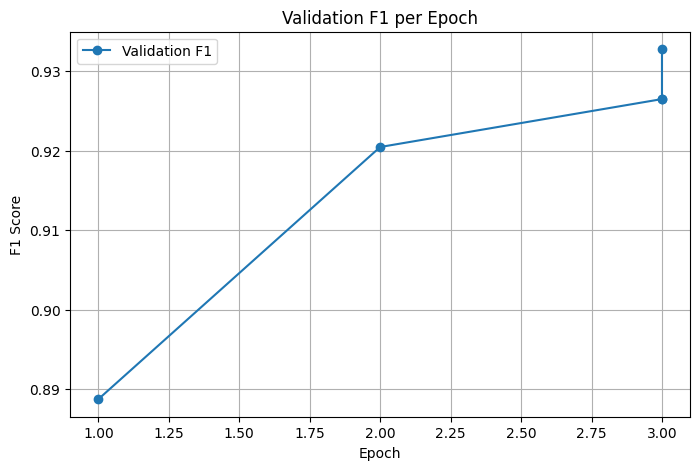

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(eval_epochs[:len(eval_f1)], eval_f1, marker="o", label="Validation F1")

plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Validation F1 per Epoch")
plt.legend()
plt.grid(True)
plt.show()

**Print the Values**

In [ ]:
print("Train Epochs:", train_epochs)
print("Train Loss:", train_loss)
print("Eval Epochs:", eval_epochs)
print("Eval Loss:", eval_loss)
print("Eval F1:", eval_f1)

Train Epochs: [1.0, 2.0, 3.0]
Train Loss: [0.1065227977395887, 0.04405698749214925, 0.034752279358775125]
Eval Epochs: [1.0, 2.0, 3.0, 3.0, 3.0]
Eval Loss: [0.04950762167572975, 0.04349658265709877, 0.04528595879673958, 0.04528595879673958, 0.04139390587806702]
Eval F1: [0.888757629454617, 0.9204491538826506, 0.926471775821691, 0.926471775821691, 0.9327372403050594]


# 12. Testing Model A on New Text

In [ ]:
model.eval()

BertForTokenClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(64000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, el

In [ ]:
text = "نظرت المحكمة التجارية في القضية رقم 12345 وألزمت المدعى عليه بدفع مبلغ 50000 ريال بتاريخ 1445/2/10"

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

inputs = tokenizer(text, return_tensors="pt", truncation=True)
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)

preds = outputs.logits.argmax(dim=2)[0].tolist()
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0].cpu())

In [ ]:
for token, pred in zip(tokens, preds):
    print(token, "→", id2label[pred])

[CLS] → O
نظرت → O
المحكمة → B-محكمة
التجارية → I-محكمة
في → I-محكمة
القضية → B-رقم_قضية
رقم → I-رقم_قضية
123 → I-رقم_قضية
##45 → I-رقم_قضية
وأل → O
##زمت → O
المدعى → O
عليه → O
بدفع → O
مبلغ → B-مبلغ_مالي
500 → I-مبلغ_مالي
##00 → I-مبلغ_مالي
ريال → I-مبلغ_مالي
بتاريخ → O
144 → O
##5 → O
[UNK] → O
2 → O
[UNK] → O
10 → O
[SEP] → O


In [ ]:
def clean_bert_token(token):
    return token.replace("##", "")

def merge_subwords(tokens):
    merged = []
    for tok in tokens:
        if tok.startswith("##") and merged:
            merged[-1] = merged[-1] + tok[2:]
        else:
            merged.append(tok)
    return merged

entities = []
current = []
current_label = None

for token, pred in zip(tokens, preds):
    label = id2label[pred]

    if token in ["[CLS]", "[SEP]", "[PAD]"]:
        continue

    if label.startswith("B-"):
        if current:
            merged = merge_subwords(current)
            entities.append((" ".join(merged), current_label))
        current = [token]
        current_label = label[2:]

    elif label.startswith("I-") and current:
        current.append(token)

    else:
        if current:
            merged = merge_subwords(current)
            entities.append((" ".join(merged), current_label))
            current = []

if current:
    merged = merge_subwords(current)
    entities.append((" ".join(merged), current_label))

print("🔹 Clean Extracted Entities:")
for e in entities:
    print(e)

🔹 Clean Extracted Entities:
('المحكمة التجارية في', 'محكمة')
('القضية رقم 12345', 'رقم_قضية')
('مبلغ 50000 ريال', 'مبلغ_مالي')


# 13. Load Sample from Test Dataset

In [ ]:
sample = test_records[0]
print(sample.keys())
print(sample["tokens"][:50])
print(sample["bio_tags"][:50])

dict_keys(['tokens', 'bio_tags', 'input_ids', 'attention_mask', 'case_id', 'segment_id'])
['[CLS]', 'الحمد', 'لله', 'والصلاة', 'والسلام', 'على', 'رسول', 'الله', ',', 'اما', 'بعد', ':', 'فل', '##دى', 'الدائرة', 'التجارية', 'العاشرة', 'وبناء', 'على', 'القضية', 'رقم', '45', '##71', '##37', '##12', '##61', 'لعام', '144', '##5', 'ه', '[UNK]', ':', 'شرك', '##ه', '(', '.', '.', '.', ')', '[UNK]', 'عليه', ':', 'شركة', '(', '.', '.', '.', ')', '[SEP]']
['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-محكمة', 'I-محكمة', 'O', 'O', 'O', 'B-رقم_قضية', 'B-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']


**Step1. Inspect Sample Structure**

In [ ]:
sample_tokens = sample["tokens"]
sample_tags = sample["bio_tags"]

print("Tokens:")
print(sample_tokens[:60])

print("\nGold BIO Tags:")
print(sample_tags[:60])

Tokens:
['[CLS]', 'الحمد', 'لله', 'والصلاة', 'والسلام', 'على', 'رسول', 'الله', ',', 'اما', 'بعد', ':', 'فل', '##دى', 'الدائرة', 'التجارية', 'العاشرة', 'وبناء', 'على', 'القضية', 'رقم', '45', '##71', '##37', '##12', '##61', 'لعام', '144', '##5', 'ه', '[UNK]', ':', 'شرك', '##ه', '(', '.', '.', '.', ')', '[UNK]', 'عليه', ':', 'شركة', '(', '.', '.', '.', ')', '[SEP]']

Gold BIO Tags:
['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-محكمة', 'I-محكمة', 'O', 'O', 'O', 'B-رقم_قضية', 'B-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'I-رقم_قضية', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']


**Step 2. Display Tokens and Gold Labels**

In [ ]:
def rebuild_text(tokens):
    clean_tokens = []
    for tok in tokens:
        if tok in ["[CLS]", "[SEP]", "[PAD]"]:
            continue
        if tok.startswith("##") and clean_tokens:
            clean_tokens[-1] = clean_tokens[-1] + tok[2:]
        else:
            clean_tokens.append(tok)
    return " ".join(clean_tokens)

text = rebuild_text(sample["tokens"])
print(text[:1000])

الحمد لله والصلاة والسلام على رسول الله , اما بعد : فلدى الدائرة التجارية العاشرة وبناء على القضية رقم 4571371261 لعام 1445 ه [UNK] : شركه ( . . . ) [UNK] عليه : شركة ( . . . )


**Step 4. Rebuild Text from Tokenized Input**

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

inputs = tokenizer(text, return_tensors="pt", truncation=True)
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)

preds = outputs.logits.argmax(dim=2)[0].tolist()
pred_tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0].cpu())

**Step 5. Preview Reconstructed Text**

In [ ]:
for token, pred in zip(pred_tokens, preds):
    print(token, "→", id2label[pred])

[CLS] → O
الحمد → O
لله → O
والصلاة → O
والسلام → O
على → O
رسول → O
الله → O
, → O
اما → O
بعد → O
: → O
فل → O
##دى → O
الدائرة → B-محكمة
التجارية → I-محكمة
العاشرة → O
وبناء → O
على → O
القضية → B-رقم_قضية
رقم → I-رقم_قضية
45 → I-رقم_قضية
##71 → I-رقم_قضية
##37 → I-رقم_قضية
##12 → I-رقم_قضية
##61 → I-رقم_قضية
لعام → I-رقم_قضية
144 → I-رقم_قضية
##5 → I-رقم_قضية
ه → O
[UNK] → O
: → O
شرك → O
##ه → O
( → O
. → O
. → O
. → O
) → O
[UNK] → O
عليه → O
: → O
شركة → O
( → O
. → O
. → O
. → O
) → O
[SEP] → O


In [ ]:
def extract_entities_from_prediction(tokens, predictions, id2label):
    entities = []
    current = []
    current_label = None

    for token, pred in zip(tokens, predictions):
        label = id2label[pred]

        if token in ["[CLS]", "[SEP]", "[PAD]"]:
            continue

        if label.startswith("B-"):
            if current:
                entities.append((" ".join(current), current_label))
            current = [token]
            current_label = label[2:]

        elif label.startswith("I-") and current:
            current.append(token)

        else:
            if current:
                entities.append((" ".join(current), current_label))
                current = []

    if current:
        entities.append((" ".join(current), current_label))

    return entities

entities = extract_entities_from_prediction(pred_tokens, preds, id2label)

print("Predicted Entities:")
for e in entities:
    print(e)

Predicted Entities:
('الدائرة التجارية', 'محكمة')
('القضية رقم 45 ##71 ##37 ##12 ##61 لعام 144 ##5', 'رقم_قضية')


In [ ]:
gold_pairs = list(zip(sample["tokens"], sample["bio_tags"]))

for tok, tag in gold_pairs[:60]:
    print(tok, "→", tag)

[CLS] → O
الحمد → O
لله → O
والصلاة → O
والسلام → O
على → O
رسول → O
الله → O
, → O
اما → O
بعد → O
: → O
فل → O
##دى → O
الدائرة → B-محكمة
التجارية → I-محكمة
العاشرة → O
وبناء → O
على → O
القضية → B-رقم_قضية
رقم → B-رقم_قضية
45 → I-رقم_قضية
##71 → I-رقم_قضية
##37 → I-رقم_قضية
##12 → I-رقم_قضية
##61 → I-رقم_قضية
لعام → I-رقم_قضية
144 → I-رقم_قضية
##5 → I-رقم_قضية
ه → O
[UNK] → O
: → O
شرك → O
##ه → O
( → O
. → O
. → O
. → O
) → O
[UNK] → O
عليه → O
: → O
شركة → O
( → O
. → O
. → O
. → O
) → O
[SEP] → O


In [ ]:
pred_labels = [id2label[p] for p in preds]

for tok, gold, pred in zip(pred_tokens, sample_tags[:len(pred_labels)], pred_labels):
    print(f"{tok:15} | Gold: {gold:15} | Pred: {pred}")

[CLS]           | Gold: O               | Pred: O
الحمد           | Gold: O               | Pred: O
لله             | Gold: O               | Pred: O
والصلاة         | Gold: O               | Pred: O
والسلام         | Gold: O               | Pred: O
على             | Gold: O               | Pred: O
رسول            | Gold: O               | Pred: O
الله            | Gold: O               | Pred: O
,               | Gold: O               | Pred: O
اما             | Gold: O               | Pred: O
بعد             | Gold: O               | Pred: O
:               | Gold: O               | Pred: O
فل              | Gold: O               | Pred: O
##دى            | Gold: O               | Pred: O
الدائرة         | Gold: B-محكمة         | Pred: B-محكمة
التجارية        | Gold: I-محكمة         | Pred: I-محكمة
العاشرة         | Gold: O               | Pred: O
وبناء           | Gold: O               | Pred: O
على             | Gold: O               | Pred: O
القضية          | Gold: B-رقم_قضية    

# 14. Manual Evaluation and Qualitative Analysis

In [ ]:
sample = test_dataset[0]

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

input_ids = torch.tensor([sample["input_ids"]]).to(device)
attention_mask = torch.tensor([sample["attention_mask"]]).to(device)

with torch.no_grad():
    outputs = model(input_ids=input_ids, attention_mask=attention_mask)

preds = outputs.logits.argmax(dim=2)[0].cpu().tolist()

In [ ]:
tokens = tokenizer.convert_ids_to_tokens(sample["input_ids"])

In [ ]:
def merge_same_label_neighbors(entities):
    if not entities:
        return entities

    merged = [entities[0]]

    for item in entities[1:]:
        last = merged[-1]
        if item["label"] == last["label"]:
            last["entity"] = last["entity"] + " " + item["entity"]
        else:
            merged.append(item)

    return merged

In [ ]:
# ========================================
# CLEAN TEXT FUNCTION
# ========================================
def fix_entity_text(text):
    parts = text.split()
    fixed = []

    for p in parts:
        p = p.replace("##", "")

        # دمج الأرقام
        if fixed and p.isdigit() and fixed[-1].isdigit():
            fixed[-1] += p
        else:
            fixed.append(p)

    # 🔥 إعادة ترتيب ذكية لرقم القضية
    digits = [p for p in fixed if p.isdigit()]
    words = [p for p in fixed if not p.isdigit()]

    case_num = ""
    year = ""

    if len(digits) >= 1:
        case_num = digits[0]

    if len(digits) >= 2:
        year = digits[1]

    # بناء النص الصحيح
    text = ""

    if "قضية" in " ".join(words) or "القضية" in " ".join(words):
        text = f"رقم القضية {case_num}"
        if year:
            text += f" لعام {year}"
    else:
        text = " ".join(fixed)

    return text.strip()



# ========================================
# EXTRACT ENTITIES FUNCTION
# ========================================
def extract_entities(tokens, labels):
    entities = []
    current = []
    current_label = None

    for tok, lab in zip(tokens, labels):

        if tok in ["[CLS]", "[SEP]", "[PAD]"]:
            continue

        tok = tok.replace("##", "")

        if lab.startswith("B-"):
            if current:
                entities.append({
                    "label": current_label,
                    "entity": fix_entity_text(" ".join(current))
                })

            current = [tok]
            current_label = lab[2:]

        elif lab.startswith("I-") and current:
            current.append(tok)

        else:
            if current:
                entities.append({
                    "label": current_label,
                    "entity": fix_entity_text(" ".join(current))
                })
                current = []
                current_label = None

    if current:
        entities.append({
            "label": current_label,
            "entity": fix_entity_text(" ".join(current))
        })

    return entities


# ========================================
# RUN
# ========================================
entities = extract_entities(tokens, pred_labels)

print("\n=== Extracted Entities ===\n")

for item in entities:
    print(f"{item['label']} ➜ {item['entity']}")


=== Extracted Entities ===

محكمة ➜ الدائرة التجارية
رقم_قضية ➜ رقم القضية 4571371261 لعام 1445


In [ ]:
entities = extract_entities(tokens, pred_labels)

for item in entities:
    print(f"{item['label']} ➜ {item['entity']}")

محكمة ➜ الدائرة التجارية
رقم_قضية ➜ رقم القضية 4571371261 لعام 1445


# Loading the Trained Model A from Kaggle Dataset

In [ ]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    if "config.json" in files and "model.safetensors" in files:
        print("MODEL PATH:", root)
        print(files)

MODEL PATH: /kaggle/input/datasets/ruofalshreef/model-a
['config.json', 'training_args.bin', 'tokenizer.json', 'tokenizer_config.json', 'model.safetensors']


In [ ]:
from transformers import AutoTokenizer, AutoModelForTokenClassification

model_path = "/kaggle/input/datasets/ruofalshreef/model-a"

tokenizer = AutoTokenizer.from_pretrained(model_path, local_files_only=True)
model = AutoModelForTokenClassification.from_pretrained(model_path, local_files_only=True)

print("Model loaded successfully ✅")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model loaded successfully ✅


---
#  Part 4: Evaluation & Testing
---

##  Model Performance Evaluation

In [ ]:
import torch

def predict(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True)

    with torch.no_grad():
        outputs = model(**inputs)

    predictions = torch.argmax(outputs.logits, dim=2)

    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    labels = predictions[0].tolist()

    return list(zip(tokens, labels))

In [ ]:
text = "نظرت المحكمة التجارية في القضية رقم 12345 وألزمت بدفع 50000 ريال"

result = predict(text)

for t, l in result:
    print(t, l)

[CLS] 0
نظرت 0
المحكمة 5
التجارية 11
في 11
القضية 3
رقم 9
123 9
##45 9
وأل 0
##زمت 0
بدفع 0
500 4
##00 10
ريال 10
[SEP] 0


# Export Model A Outputs for Model B

In [ ]:
import json
import torch

label_list = [
    "O",
    "B-اسم_نظام", "B-تاريخ", "B-رقم_قضية", "B-مبلغ_مالي", "B-محكمة", "B-مرجع_قانوني",
    "I-اسم_نظام", "I-تاريخ", "I-رقم_قضية", "I-مبلغ_مالي", "I-محكمة", "I-مرجع_قانوني"
]

def clean_token(token):
    return token.replace("##", "")

def extract_entities_for_model_b(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)

    with torch.no_grad():
        outputs = model(**inputs)

    preds = torch.argmax(outputs.logits, dim=2)[0]
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    labels = [label_list[p.item()] for p in preds]

    entities = []
    current_tokens = []
    current_label = None

    for token, label in zip(tokens, labels):
        if token in ["[CLS]", "[SEP]"]:
            continue

        if label.startswith("B-"):
            if current_tokens:
                entities.append({
                    "text": "".join([clean_token(t) if t.startswith("##") else " " + clean_token(t) for t in current_tokens]).strip(),
                    "label": current_label
                })

            current_tokens = [token]
            current_label = label[2:]

        elif label.startswith("I-") and current_label == label[2:]:
            current_tokens.append(token)

        else:
            if current_tokens:
                entities.append({
                    "text": "".join([clean_token(t) if t.startswith("##") else " " + clean_token(t) for t in current_tokens]).strip(),
                    "label": current_label
                })
            current_tokens = []
            current_label = None

    if current_tokens:
        entities.append({
            "text": "".join([clean_token(t) if t.startswith("##") else " " + clean_token(t) for t in current_tokens]).strip(),
            "label": current_label
        })

    return entities

In [ ]:
case_text = "نظرت المحكمة التجارية في القضية رقم 12345 وألزمت بدفع 50000 ريال"

model_b_input = {
    "case_text": case_text,
    "model_a_entities": extract_entities_for_model_b(case_text)
}

with open("/kaggle/working/model_b_input_sample.json", "w", encoding="utf-8") as f:
    json.dump(model_b_input, f, ensure_ascii=False, indent=2)

print(model_b_input)

{'case_text': 'نظرت المحكمة التجارية في القضية رقم 12345 وألزمت بدفع 50000 ريال', 'model_a_entities': [{'text': 'المحكمة التجارية في', 'label': 'محكمة'}, {'text': 'القضية رقم 12345', 'label': 'رقم_قضية'}, {'text': '50000 ريال', 'label': 'مبلغ_مالي'}]}


In [ ]:
def join_tokens(tokens):
    text = ""

    for tok in tokens:
        if tok.startswith("##"):
            text += tok[2:]
        else:
            if text:
                text += " "
            text += tok

    return text


def clean_entity_text(text):
    unwanted_words = ["في", "على", "من", "إلى", "عن", "و"]
    words = text.split()

    while words and words[-1] in unwanted_words:
        words.pop()

    return " ".join(words)


def extract_entities_for_model_b(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)

    with torch.no_grad():
        outputs = model(**inputs)

    preds = torch.argmax(outputs.logits, dim=2)[0]
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    labels = [label_list[p.item()] for p in preds]

    entities = []
    current_tokens = []
    current_label = None

    for token, label in zip(tokens, labels):
        if token in ["[CLS]", "[SEP]", "[PAD]"]:
            continue

        if label.startswith("B-"):
            if current_tokens:
                entity_text = join_tokens(current_tokens)
                entities.append({
                    "text": clean_entity_text(entity_text),
                    "label": current_label
                })

            current_tokens = [token]
            current_label = label[2:]

        elif label.startswith("I-") and current_label == label[2:]:
            current_tokens.append(token)

        else:
            if current_tokens:
                entity_text = join_tokens(current_tokens)
                entities.append({
                    "text": clean_entity_text(entity_text),
                    "label": current_label
                })

            current_tokens = []
            current_label = None

    if current_tokens:
        entity_text = join_tokens(current_tokens)
        entities.append({
            "text": clean_entity_text(entity_text),
            "label": current_label
        })

    return entities

In [ ]:
text = "نظرت المحكمة التجارية في القضية رقم 12345 وألزمت بدفع 50000 ريال"
entities = extract_entities_for_model_b(text)
print(entities)

[{'text': 'المحكمة التجارية', 'label': 'محكمة'}, {'text': 'القضية رقم 12345', 'label': 'رقم_قضية'}, {'text': '50000 ريال', 'label': 'مبلغ_مالي'}]


In [ ]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if "03_segmented" in f:
            print(os.path.join(root, f))

/kaggle/input/datasets/ruofalshreef/segment/03_segmented (5).csv


In [ ]:
import pandas as pd

SEGMENTED_PATH = "/kaggle/input/datasets/ruofalshreef/segment/03_segmented (5).csv"

df = pd.read_csv(SEGMENTED_PATH)

print(df.shape)
df.head()

(114923, 8)


,segment_id,case_id,segment_order,section_heading,segment_text,segment_text_clean,segment_type,char_count
0,77a6423b-64c2-4c1e-91e1-a66fb0a2754a,Oo52663n_4unagKCkqMqMPqxqIrp_TBHNN64f2qt9RnGeG...,0,header,الحمد لله والصلاة والسلام على رسول الله :اما ب...,الحمد لله والصلاة والسلام على رسول الله :اما ب...,Header,205
1,8fc11fe0-b165-4153-b5ec-a88050e08550,Oo52663n_4unagKCkqMqMPqxqIrp_TBHNN64f2qt9RnGeG...,1,NaN,الحمد لله والصلاة والسلام على رسول الله :اما ب...,الحمد لله والصلاة والسلام على رسول الله :اما ب...,Other,205
2,2d4f8575-c125-4f78-917b-e798d68f7f63,Oo52663n_4unagKCkqMqMPqxqIrp_TBHNN64f2qt9RnGeG...,2,الوقائع,تتلخص وقائع هذه القضية بالقدر اللازم للحكم فيه...,تتلخص وقائع هذه القضية بالقدر اللازم للحكم فيه...,Fact,219
3,78024abb-dcd2-432b-b411-cbb97c77658a,Oo52663n_4unagKCkqMqMPqxqIrp_TBHNN64f2qt9RnGeG...,3,الرد,عليها برقم.. الى المحكمة التجارية بالرياض بصحي...,عليها برقم.. الى المحكمة التجارية بالرياض بصحي...,Procedural,1891
4,aa5fa830-50b6-46e2-a46c-9084a42b1c3d,Oo52663n_4unagKCkqMqMPqxqIrp_TBHNN64f2qt9RnGeG...,4,الطلبات,1) فسخ العقد R22 004 C01.SC. 2) الزام المدّعى ...,1) فسخ العقد R22 004 C01.SC. 2) الزام المدّعى ...,Request,309


In [ ]:
grouped_cases = (
    df.sort_values(["case_id", "segment_order"])
    .groupby("case_id")["segment_text"]
    .apply(lambda x: " ".join(x.astype(str)))
    .reset_index()
)

print("Number of cases:", len(grouped_cases))
grouped_cases.head()

Number of cases: 4677


,case_id,segment_text
0,-0Qi1QrIB_VswTxs9euKkzkSYK5FNUJsumSpvjxiVAA01_...,الحمدلله والصلاة والسلام على رسول الله، اما بع...
1,-0pdRshMCMX524qdzeEZCNN_Mqv9vqZrgU6BDdHwsfQyVl...,الحمدلله والصلاة والسلام على رسول الله: اما بع...
2,-25yZyu7MgZokxzWse0QFKfOhfu3WUIbfcysa0rAM3XRNt...,الحمد لله والصلاة والسلام على رسول الله، اما ب...
3,-3laganFquUN8WcZB2W7gf4lZQF-X5kqjWCmJhz7Sgd668...,الحمدلله والصلاة والسلام على رسول الله اما بعد...
4,-438S9cCOMx1tPwiQZ301cHHr5Z-BKfvEQQWeVXBPJLs9J...,الحمدلله والصلاة والسلام على رسول الله، اما بع...


In [ ]:
sample_text = grouped_cases.iloc[0]["segment_text"]

entities = extract_entities_for_model_b(sample_text)

print("Text sample:")
print(sample_text[:500])

print("\nEntities:")
print(entities[:20])

Text sample:
الحمدلله والصلاة والسلام على رسول الله، اما بعد: فلدى الدائرة التجارية الثانية عشرة وبناء على القضية رقم 4470860022 لعام 1444 ه المدّعي: مؤسسة لايت ستار للادوات الكهربائية المدّعى عليه: مؤسسة نجف الجزيرة للتجارة الحمدلله والصلاة والسلام على رسول الله، اما بعد: فلدى الدائرة التجارية الثانية عشرة وبناء على القضية رقم 4470860022 لعام 1444 ه المدّعي: مؤسسة لايت ستار للادوات الكهربائية المدّعى عليه: مؤسسة نجف الجزيرة للتجارة تتلخص وقائع هذه الدعوى في انه سبق ان تقدم وكيل المدّعي الموضح بياناته اعلاه 

Entities:
[{'text': 'الدائرة التجارية', 'label': 'محكمة'}, {'text': 'القضية رقم 4470860022 لعام 1444', 'label': 'رقم_قضية'}, {'text': 'الدائرة التجارية', 'label': 'محكمة'}, {'text': 'القضية رقم 4470860022 لعام 1444', 'label': 'رقم_قضية'}, {'text': 'المحكمة التجارية بجدة', 'label': 'محكمة'}, {'text': '12 [UNK] 09 [UNK] 1444 ه', 'label': 'تاريخ'}, {'text': 'النظام ونصها', 'label': 'اسم_نظام'}, {'text': '13 [UNK] 9 [UNK] 2020م', 'label': 'تاريخ'}, {'text': '24 [UNK] 1 [UNK] 2021م', '

In [ ]:
def deduplicate_entities(entities):
    seen = set()
    clean_entities = []

    for ent in entities:
        key = (ent["text"], ent["label"])
        if key not in seen:
            seen.add(key)
            clean_entities.append(ent)

    return clean_entities

In [ ]:

        "case_text": text,
        "model_a_entities": entities
    })

    if i % 100 == 0:
        print(f"Processed {i}/{len(grouped_cases)}")

Processed 0/4677
Processed 100/4677
Processed 200/4677
Processed 300/4677
Processed 400/4677
Processed 500/4677
Processed 600/4677
Processed 700/4677
Processed 800/4677
Processed 900/4677
Processed 1000/4677
Processed 1100/4677
Processed 1200/4677
Processed 1300/4677
Processed 1400/4677
Processed 1500/4677
Processed 1600/4677
Processed 1700/4677
Processed 1800/4677
Processed 1900/4677
Processed 2000/4677
Processed 2100/4677
Processed 2200/4677
Processed 2300/4677
Processed 2400/4677
Processed 2500/4677
Processed 2600/4677
Processed 2700/4677
Processed 2800/4677
Processed 2900/4677
Processed 3000/4677
Processed 3100/4677
Processed 3200/4677
Processed 3300/4677
Processed 3400/4677
Processed 3500/4677
Processed 3600/4677
Processed 3700/4677
Processed 3800/4677
Processed 3900/4677
Processed 4000/4677
Processed 4100/4677
Processed 4200/4677
Processed 4300/4677
Processed 4400/4677
Processed 4500/4677
Processed 4600/4677


In [ ]:
print(len(model_b_data))

4677


In [ ]:
empty_cases = [x for x in model_b_data if not x["case_text"]]
empty_entities = [x for x in model_b_data if not x["model_a_entities"]]

print("Empty texts:", len(empty_cases))
print("Empty entities:", len(empty_entities))

Empty texts: 0
Empty entities: 0


In [ ]:
print(model_b_data[0])

{'case_id': '-0Qi1QrIB_VswTxs9euKkzkSYK5FNUJsumSpvjxiVAA01_vhEemhbC8ee-IyhBZk', 'case_text': 'الحمدلله والصلاة والسلام على رسول الله، اما بعد: فلدى الدائرة التجارية الثانية عشرة وبناء على القضية رقم 4470860022 لعام 1444 ه المدّعي: مؤسسة لايت ستار للادوات الكهربائية المدّعى عليه: مؤسسة نجف الجزيرة للتجارة الحمدلله والصلاة والسلام على رسول الله، اما بعد: فلدى الدائرة التجارية الثانية عشرة وبناء على القضية رقم 4470860022 لعام 1444 ه المدّعي: مؤسسة لايت ستار للادوات الكهربائية المدّعى عليه: مؤسسة نجف الجزيرة للتجارة تتلخص وقائع هذه الدعوى في انه سبق ان تقدم وكيل المدّعي الموضح بياناته اعلاه بلائحة دعوى الى المحكمة التجارية بجدة ذكر فيها: انه بتاريخ 1442/01/12ه الموافق 2020/08/31م -تقريبا- اتفق اطراف الدعوى على ان يورد المدّعي للمدعى عليه (ادوات كهربائية) وتاريخ ابتداء التعامل 1442/01/12ه الموافق 2020/08/31م بثمن اجمالي قدره (100,000.00) مائة الف ريال سعودي سدد منه (42,328.00) اثنان واربعون الفا وثلاث مئة وثمانية وعشرون ريال سعودي، وقد استلم المدّعى عليه كامل المبيع ولم يتم تحديد مدة العقد،

In [ ]:
def clean_entity_text(text):
    text = text.replace("[UNK]", "")
    text = " ".join(text.split())
    return text.strip()

def remove_duplicate_entities(entities):
    seen = set()
    unique = []
    for e in entities:
        key = (e["text"], e["label"])
        if key not in seen:
            seen.add(key)
            unique.append(e)
    return unique

def filter_entities(entities):
    clean = []
    for e in entities:
        txt = e["text"]

        if len(txt) < 4:
            continue
        if "..." in txt:
            continue
        if "النظام ونصها" in txt:
            continue
        if txt == "":
            continue

        clean.append(e)

    return clean

In [ ]:
sample_text = grouped_cases.iloc[0]["segment_text"]

entities = extract_entities_for_model_b(sample_text)
entities = [{**e, "text": clean_entity_text(e["text"])} for e in entities]
entities = remove_duplicate_entities(entities)
entities = filter_entities(entities)

print(entities)

[{'text': 'الدائرة التجارية', 'label': 'محكمة'}, {'text': 'القضية رقم 4470860022 لعام 1444', 'label': 'رقم_قضية'}, {'text': 'المحكمة التجارية بجدة', 'label': 'محكمة'}, {'text': '12 09 1444 ه', 'label': 'تاريخ'}, {'text': '13 9 2020م', 'label': 'تاريخ'}, {'text': '24 1 2021م', 'label': 'تاريخ'}]


In [ ]:
def remove_duplicate_entities(entities):
    seen = set()
    unique = []

    for e in entities:
        key = (e["text"], e["label"])
        if key not in seen:
            seen.add(key)
            unique.append(e)

    return unique

In [ ]:
def clean_entity_text(text):
    text = text.replace("[UNK]", "")
    text = text.replace("  ", " ")
    return text.strip()

In [ ]:
def filter_entities(entities):
    clean = []

    for e in entities:
        if len(e["text"]) < 4:
            continue
        if "..." in e["text"]:
            continue
        if "النظام ونصها" in e["text"]:
            continue

        clean.append(e)

    return clean

In [ ]:
model_b_data = []

for i, row in grouped_cases.iterrows():
    text = row["segment_text"]

    entities = extract_entities_for_model_b(text)
    entities = [{**e, "text": clean_entity_text(e["text"])} for e in entities]
    entities = remove_duplicate_entities(entities)
    entities = filter_entities(entities)

    model_b_data.append({
        "case_id": row["case_id"],
        "case_text": text,
        "model_a_entities": entities
    })

    if i % 100 == 0:
        print(f"Processed {i}/{len(grouped_cases)}")

Processed 0/4677
Processed 100/4677
Processed 200/4677
Processed 300/4677
Processed 400/4677
Processed 500/4677
Processed 600/4677
Processed 700/4677
Processed 800/4677
Processed 900/4677
Processed 1000/4677
Processed 1100/4677
Processed 1200/4677
Processed 1300/4677
Processed 1400/4677
Processed 1500/4677
Processed 1600/4677
Processed 1700/4677
Processed 1800/4677
Processed 1900/4677
Processed 2000/4677
Processed 2100/4677
Processed 2200/4677
Processed 2300/4677
Processed 2400/4677
Processed 2500/4677
Processed 2600/4677
Processed 2700/4677
Processed 2800/4677
Processed 2900/4677
Processed 3000/4677
Processed 3100/4677
Processed 3200/4677
Processed 3300/4677
Processed 3400/4677
Processed 3500/4677
Processed 3600/4677
Processed 3700/4677
Processed 3800/4677
Processed 3900/4677
Processed 4000/4677
Processed 4100/4677
Processed 4200/4677
Processed 4300/4677
Processed 4400/4677
Processed 4500/4677
Processed 4600/4677


# Define Party Extraction Function

**Detect Placeholder**

In [ ]:
def is_placeholder(text):
    return "..." in text or "(...)" in text

**Replace Based on Label**

In [ ]:
def fix_party_entity(entity):
    text = entity["text"]
    label = entity["label"]

    if is_placeholder(text):
        if label == "مدعي":
            text = "[PLAINTIFF]"
        elif label == "مدعى_عليه":
            text = "[DEFENDANT]"

    return {
        "text": text,
        "label": label
    }

In [ ]:
party_entities = [fix_party_entity(e) for e in party_entities]

NameError: name 'party_entities' is not defined

In [ ]:
sample_text = grouped_cases.iloc[0]["segment_text"]

# استخراج
party_entities = extract_parties_from_text(sample_text)

# تطبيق placeholder
party_entities = [fix_party_entity(e) for e in party_entities]

print(party_entities)

[{'text': 'مؤسسة لايت ستار للادوات الكهربائية', 'label': 'مدعي'}, {'text': 'مؤسسة نجف الجزيرة للتجارة الحمدلله والصلاة والسلام على رسول الله، اما بعد: فلدى الدائرة التجارية الثانية عشرة وبناء على القضية رقم 4470860022 لعام 1444 ه', 'label': 'مدعى_عليه'}]


In [ ]:
import re

def extract_parties_from_text(text):
    parties = []

    plaintiff_pattern = r"المدّ?عي\s*:\s*(.*?)(?=\s+المدّ?عى عليه\s*:|\n|$)"

    defendant_pattern = (
        r"المدّ?عى عليه\s*:\s*(.*?)"
        r"(?=\s+الحمدلله|\s+الحمد لله|\s+تتلخص|\s+وقائع|\s+الاسباب|\s+حكمت|\n|$)"
    )

    plaintiff = re.search(plaintiff_pattern, text)
    defendant = re.search(defendant_pattern, text)

    if plaintiff:
        parties.append({
            "text": clean_entity_text(plaintiff.group(1)),
            "label": "مدعي"
        })

    if defendant:
        parties.append({
            "text": clean_entity_text(defendant.group(1)),
            "label": "مدعى_عليه"
        })

    return parties

In [ ]:
party_entities = extract_parties_from_text(sample_text)
party_entities = [fix_party_entity(e) for e in party_entities]

print(party_entities)

[{'text': 'مؤسسة لايت ستار للادوات الكهربائية', 'label': 'مدعي'}, {'text': 'مؤسسة نجف الجزيرة للتجارة', 'label': 'مدعى_عليه'}]


In [ ]:
def extract_parties_from_text(text):
    parties = []

    plaintiff_pattern = r"المدّ?عي\s*:\s*(.*?)(?=\s+المدّ?عى عليه\s*:|\n|$)"

    defendant_pattern = (
        r"المدّ?عى عليه\s*:\s*(.*?)"
        r"(?=\s+الحمدلله|\s+الحمد لله|\s+تتلخص|\s+وقائع|\s+الاسباب|\s+حكمت|\n|$)"
    )

    plaintiff = re.search(plaintiff_pattern, text)
    defendant = re.search(defendant_pattern, text)

    # ✔ إذا موجود
    if plaintiff:
        parties.append({
            "text": clean_entity_text(plaintiff.group(1)),
            "label": "مدعي"
        })
    else:
        #  fallback
        parties.append({
            "text": "[PLAINTIFF]",
            "label": "مدعي"
        })

    if defendant:
        parties.append({
            "text": clean_entity_text(defendant.group(1)),
            "label": "مدعى_عليه"
        })
    else:
        # 🔥 fallback
        parties.append({
            "text": "[DEFENDANT]",
            "label": "مدعى_عليه"
        })

    return parties

In [ ]:
test_text = "نظرت المحكمة التجارية في القضية رقم 12345 وأصدرت الحكم..."

print(extract_parties_from_text(test_text))

[{'text': '[PLAINTIFF]', 'label': 'مدعي'}, {'text': '[DEFENDANT]', 'label': 'مدعى_عليه'}]


In [ ]:
for i, row in grouped_cases.head(5).iterrows():
    text = row["segment_text"]

    parties = extract_parties_from_text(text)

    print(f"\nCase {i}")
    print(parties)


Case 0
[{'text': 'مؤسسة لايت ستار للادوات الكهربائية', 'label': 'مدعي'}, {'text': 'مؤسسة نجف الجزيرة للتجارة', 'label': 'مدعى_عليه'}]

Case 1
[{'text': 'شركة بزل المحدودة', 'label': 'مدعي'}, {'text': 'سعد عبدالعزيز سعد بن خنين', 'label': 'مدعى_عليه'}]

Case 2
[{'text': '(...)', 'label': 'مدعي'}, {'text': '(...)', 'label': 'مدعى_عليه'}]

Case 3
[{'text': 'ابراهيم عمر سليم عرنوس', 'label': 'مدعي'}, {'text': 'محمد بن عمر بن سليم عرنوس', 'label': 'مدعى_عليه'}]

Case 4
[{'text': 'شركة افق البنية التحتية للمقاولات شركة شخص واحد', 'label': 'مدعي'}, {'text': 'مصنع شركة حواء للوحات التوزيع الكهربائية', 'label': 'مدعى_عليه'}]


# Structured Input for Model B

In [ ]:
import torch

label_list = [
    "O",
    "B-اسم_نظام", "B-تاريخ", "B-رقم_قضية", "B-مبلغ_مالي", "B-محكمة", "B-مرجع_قانوني",
    "I-اسم_نظام", "I-تاريخ", "I-رقم_قضية", "I-مبلغ_مالي", "I-محكمة", "I-مرجع_قانوني"
]

def join_tokens(tokens):
    text = ""
    for tok in tokens:
        if tok.startswith("##"):
            text += tok[2:]
        else:
            if text:
                text += " "
            text += tok
    return text

def extract_entities_for_model_b(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)

    with torch.no_grad():
        outputs = model(**inputs)

    preds = torch.argmax(outputs.logits, dim=2)[0]
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    labels = [label_list[p.item()] for p in preds]

    entities = []
    current_tokens = []
    current_label = None

    for token, label in zip(tokens, labels):
        if token in ["[CLS]", "[SEP]", "[PAD]"]:
            continue

        if label.startswith("B-"):
            if current_tokens:
                entities.append({
                    "text": join_tokens(current_tokens),
                    "label": current_label
                })
            current_tokens = [token]
            current_label = label[2:]

        elif label.startswith("I-") and current_label == label[2:]:
            current_tokens.append(token)

        else:
            if current_tokens:
                entities.append({
                    "text": join_tokens(current_tokens),
                    "label": current_label
                })
            current_tokens = []
            current_label = None

    if current_tokens:
        entities.append({
            "text": join_tokens(current_tokens),
            "label": current_label
        })

    return entities

In [ ]:
from transformers import AutoTokenizer, AutoModelForTokenClassification

model_path = "/kaggle/input/datasets/ruofalshreef/model-a"  # أو المسار حقك

tokenizer = AutoTokenizer.from_pretrained(model_path, local_files_only=True)
model = AutoModelForTokenClassification.from_pretrained(model_path, local_files_only=True)

print("✅ tokenizer + model جاهزين")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ tokenizer + model جاهزين


In [ ]:
test_entities = extract_entities_for_model_b(grouped_cases.iloc[0]["segment_text"])
print(test_entities[:5])

[{'text': 'الدائرة التجارية', 'label': 'محكمة'}, {'text': 'القضية رقم 4470860022 لعام 1444', 'label': 'رقم_قضية'}, {'text': 'الدائرة التجارية', 'label': 'محكمة'}, {'text': 'القضية رقم 4470860022 لعام 1444', 'label': 'رقم_قضية'}, {'text': 'المحكمة التجارية بجدة', 'label': 'محكمة'}]


In [ ]:
parties = extract_parties_from_text(text)
parties = [fix_party_entity(e) for e in parties]

NameError: name 'extract_parties_from_text' is not defined

In [ ]:
for i, row in grouped_cases.head(5).iterrows():
    text = row["segment_text"]

    parties = extract_parties_from_text(text)
    parties = [fix_party_entity(e) for e in parties]

    print(f"\nCase {i}")
    print(parties)


Case 0
[{'text': 'مؤسسة لايت ستار للادوات الكهربائية', 'label': 'مدعي'}, {'text': 'مؤسسة نجف الجزيرة للتجارة', 'label': 'مدعى_عليه'}]

Case 1
[{'text': 'شركة بزل المحدودة', 'label': 'مدعي'}, {'text': 'سعد عبدالعزيز سعد بن خنين', 'label': 'مدعى_عليه'}]

Case 2
[{'text': '[PLAINTIFF]', 'label': 'مدعي'}, {'text': '[DEFENDANT]', 'label': 'مدعى_عليه'}]

Case 3
[{'text': 'ابراهيم عمر سليم عرنوس', 'label': 'مدعي'}, {'text': 'محمد بن عمر بن سليم عرنوس', 'label': 'مدعى_عليه'}]

Case 4
[{'text': 'شركة افق البنية التحتية للمقاولات شركة شخص واحد', 'label': 'مدعي'}, {'text': 'مصنع شركة حواء للوحات التوزيع الكهربائية', 'label': 'مدعى_عليه'}]


---
#  Part 5: Save Results & Export
---

##  Extract Results & Prepare Model B Input

In [ ]:
import re
import torch

# =========================
# CLEANING FUNCTIONS
# =========================
def clean_entity_text(text):
    text = text.replace("[UNK]", "")
    text = " ".join(text.split())
    return text.strip()

def remove_duplicate_entities(entities):
    seen = set()
    unique = []

    for e in entities:
        key = (e["text"], e["label"])
        if key not in seen:
            seen.add(key)
            unique.append(e)

    return unique

def filter_entities(entities):
    clean = []

    for e in entities:
        txt = e["text"]

        if len(txt) < 4:
            continue
        if "..." in txt:
            continue
        if "النظام ونصها" in txt:
            continue
        if txt == "":
            continue

        clean.append(e)

    return clean

# =========================
# MODEL A ENTITY EXTRACTION
# =========================
def join_tokens(tokens):
    text = ""
    for tok in tokens:
        if tok.startswith("##"):
            text += tok[2:]
        else:
            if text:
                text += " "
            text += tok
    return text


def extract_entities_for_model_b(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)

    with torch.no_grad():
        outputs = model(**inputs)

    preds = torch.argmax(outputs.logits, dim=2)[0]
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    labels = [label_list[p.item()] for p in preds]

    entities = []
    current_tokens = []
    current_label = None

    for token, label in zip(tokens, labels):
        if token in ["[CLS]", "[SEP]", "[PAD]"]:
            continue

        if label.startswith("B-"):
            if current_tokens:
                entity_text = join_tokens(current_tokens)
                entities.append({
                    "text": clean_entity_text(entity_text),
                    "label": current_label
                })

            current_tokens = [token]
            current_label = label[2:]

        elif label.startswith("I-") and current_label == label[2:]:
            current_tokens.append(token)

        else:
            if current_tokens:
                entity_text = join_tokens(current_tokens)
                entities.append({
                    "text": clean_entity_text(entity_text),
                    "label": current_label
                })

            current_tokens = []
            current_label = None

    if current_tokens:
        entity_text = join_tokens(current_tokens)
        entities.append({
            "text": clean_entity_text(entity_text),
            "label": current_label
        })

    return entities


# =========================
# PARTY EXTRACTION (REGEX)
# =========================
def extract_parties_from_text(text):
    parties = []

    plaintiff_pattern = r"المدّ?عي\s*:\s*(.*?)(?=\s+المدّ?عى عليه\s*:|\n|$)"

    defendant_pattern = (
        r"المدّ?عى عليه\s*:\s*(.*?)"
        r"(?=\s+الحمدلله|\s+الحمد لله|\s+تتلخص|\s+وقائع|\s+الاسباب|\s+حكمت|\n|$)"
    )

    plaintiff = re.search(plaintiff_pattern, text)
    defendant = re.search(defendant_pattern, text)

    if plaintiff:
        parties.append({
            "text": clean_entity_text(plaintiff.group(1)),
            "label": "مدعي"
        })
    else:
        parties.append({
            "text": "[PLAINTIFF]",
            "label": "مدعي"
        })

    if defendant:
        parties.append({
            "text": clean_entity_text(defendant.group(1)),
            "label": "مدعى_عليه"
        })
    else:
        parties.append({
            "text": "[DEFENDANT]",
            "label": "مدعى_عليه"
        })

    return parties


def fix_party_entity(entity):
    text = entity["text"]
    label = entity["label"]

    if "..." in text or "(...)" in text:
        if label == "مدعي":
            text = "[PLAINTIFF]"
        elif label == "مدعى_عليه":
            text = "[DEFENDANT]"

    return {"text": text, "label": label}


# =========================
# FINAL PIPELINE FUNCTION
# =========================
def build_entities(text):

    # Model A
    entities = extract_entities_for_model_b(text)

    # Parties
    parties = extract_parties_from_text(text)
    parties = [fix_party_entity(e) for e in parties]

    # Merge
    entities.extend(parties)

    # Clean
    entities = [{**e, "text": clean_entity_text(e["text"])} for e in entities]
    entities = remove_duplicate_entities(entities)
    entities = filter_entities(entities)

    return entities

In [ ]:
entities = build_entities(grouped_cases.iloc[0]["segment_text"])
print(entities)

[{'text': 'الدائرة التجارية', 'label': 'محكمة'}, {'text': 'القضية رقم 4470860022 لعام 1444', 'label': 'رقم_قضية'}, {'text': 'المحكمة التجارية بجدة', 'label': 'محكمة'}, {'text': '12 09 1444 ه', 'label': 'تاريخ'}, {'text': '13 9 2020م', 'label': 'تاريخ'}, {'text': '24 1 2021م', 'label': 'تاريخ'}, {'text': 'مؤسسة لايت ستار للادوات الكهربائية', 'label': 'مدعي'}, {'text': 'مؤسسة نجف الجزيرة للتجارة', 'label': 'مدعى_عليه'}]


In [ ]:
for i, row in grouped_cases.head(5).iterrows():
    text = row["segment_text"]

    parties = extract_parties_from_text(text)
    parties = [fix_party_entity(e) for e in parties]

    print(f"\nCase {i}")
    print(parties)


Case 0
[{'text': 'مؤسسة لايت ستار للادوات الكهربائية', 'label': 'مدعي'}, {'text': 'مؤسسة نجف الجزيرة للتجارة', 'label': 'مدعى_عليه'}]

Case 1
[{'text': 'شركة بزل المحدودة', 'label': 'مدعي'}, {'text': 'سعد عبدالعزيز سعد بن خنين', 'label': 'مدعى_عليه'}]

Case 2
[{'text': '[PLAINTIFF]', 'label': 'مدعي'}, {'text': '[DEFENDANT]', 'label': 'مدعى_عليه'}]

Case 3
[{'text': 'ابراهيم عمر سليم عرنوس', 'label': 'مدعي'}, {'text': 'محمد بن عمر بن سليم عرنوس', 'label': 'مدعى_عليه'}]

Case 4
[{'text': 'شركة افق البنية التحتية للمقاولات شركة شخص واحد', 'label': 'مدعي'}, {'text': 'مصنع شركة حواء للوحات التوزيع الكهربائية', 'label': 'مدعى_عليه'}]


# Build Model B Input with Cleaned and Enriched Entities

In [ ]:
import pandas as pd

SEGMENTED_PATH = "/kaggle/input/datasets/ruofalshreef/segment/03_segmented (5).csv"

segmented_df = pd.read_csv(SEGMENTED_PATH)

print(segmented_df.shape)
segmented_df.head()

(114923, 8)


,segment_id,case_id,segment_order,section_heading,segment_text,segment_text_clean,segment_type,char_count
0,77a6423b-64c2-4c1e-91e1-a66fb0a2754a,Oo52663n_4unagKCkqMqMPqxqIrp_TBHNN64f2qt9RnGeG...,0,header,الحمد لله والصلاة والسلام على رسول الله :اما ب...,الحمد لله والصلاة والسلام على رسول الله :اما ب...,Header,205
1,8fc11fe0-b165-4153-b5ec-a88050e08550,Oo52663n_4unagKCkqMqMPqxqIrp_TBHNN64f2qt9RnGeG...,1,NaN,الحمد لله والصلاة والسلام على رسول الله :اما ب...,الحمد لله والصلاة والسلام على رسول الله :اما ب...,Other,205
2,2d4f8575-c125-4f78-917b-e798d68f7f63,Oo52663n_4unagKCkqMqMPqxqIrp_TBHNN64f2qt9RnGeG...,2,الوقائع,تتلخص وقائع هذه القضية بالقدر اللازم للحكم فيه...,تتلخص وقائع هذه القضية بالقدر اللازم للحكم فيه...,Fact,219
3,78024abb-dcd2-432b-b411-cbb97c77658a,Oo52663n_4unagKCkqMqMPqxqIrp_TBHNN64f2qt9RnGeG...,3,الرد,عليها برقم.. الى المحكمة التجارية بالرياض بصحي...,عليها برقم.. الى المحكمة التجارية بالرياض بصحي...,Procedural,1891
4,aa5fa830-50b6-46e2-a46c-9084a42b1c3d,Oo52663n_4unagKCkqMqMPqxqIrp_TBHNN64f2qt9RnGeG...,4,الطلبات,1) فسخ العقد R22 004 C01.SC. 2) الزام المدّعى ...,1) فسخ العقد R22 004 C01.SC. 2) الزام المدّعى ...,Request,309


In [ ]:
grouped_cases = (
    segmented_df.sort_values(["case_id", "segment_order"])
    .groupby("case_id")["segment_text"]
    .apply(lambda x: " ".join(x.astype(str)))
    .reset_index()
)

print("Number of cases:", len(grouped_cases))
grouped_cases.head()

Number of cases: 4677


,case_id,segment_text
0,-0Qi1QrIB_VswTxs9euKkzkSYK5FNUJsumSpvjxiVAA01_...,الحمدلله والصلاة والسلام على رسول الله، اما بع...
1,-0pdRshMCMX524qdzeEZCNN_Mqv9vqZrgU6BDdHwsfQyVl...,الحمدلله والصلاة والسلام على رسول الله: اما بع...
2,-25yZyu7MgZokxzWse0QFKfOhfu3WUIbfcysa0rAM3XRNt...,الحمد لله والصلاة والسلام على رسول الله، اما ب...
3,-3laganFquUN8WcZB2W7gf4lZQF-X5kqjWCmJhz7Sgd668...,الحمدلله والصلاة والسلام على رسول الله اما بعد...
4,-438S9cCOMx1tPwiQZ301cHHr5Z-BKfvEQQWeVXBPJLs9J...,الحمدلله والصلاة والسلام على رسول الله، اما بع...


In [ ]:
model_b_data = []

for i, row in grouped_cases.iterrows():
    text = row["segment_text"]

    entities = build_entities(text)

    model_b_data.append({
        "case_id": row["case_id"],
        "case_text": text,
        "model_a_entities": entities
    })

    if i % 100 == 0:
        print(f"Processed {i}/{len(grouped_cases)}")

print("Done:", len(model_b_data))

Processed 0/4677
Processed 100/4677
Processed 200/4677
Processed 300/4677
Processed 400/4677
Processed 500/4677
Processed 600/4677
Processed 700/4677
Processed 800/4677
Processed 900/4677
Processed 1000/4677
Processed 1100/4677
Processed 1200/4677
Processed 1300/4677
Processed 1400/4677
Processed 1500/4677
Processed 1600/4677
Processed 1700/4677
Processed 1800/4677
Processed 1900/4677
Processed 2000/4677
Processed 2100/4677
Processed 2200/4677
Processed 2300/4677
Processed 2400/4677
Processed 2500/4677
Processed 2600/4677
Processed 2700/4677
Processed 2800/4677
Processed 2900/4677
Processed 3000/4677
Processed 3100/4677
Processed 3200/4677
Processed 3300/4677
Processed 3400/4677
Processed 3500/4677
Processed 3600/4677
Processed 3700/4677
Processed 3800/4677
Processed 3900/4677
Processed 4000/4677
Processed 4100/4677
Processed 4200/4677
Processed 4300/4677
Processed 4400/4677
Processed 4500/4677
Processed 4600/4677
Done: 4677


In [ ]:
import random

for i in random.sample(range(len(model_b_data)), 3):
    print(f"\n=== Case {i} ===")
    print("Text:", model_b_data[i]["case_text"][:200])
    print("Entities:", model_b_data[i]["model_a_entities"])


=== Case 2121 ===
Text: الحمد لله والصلاة والسلام على رسول الله اما بعد: فلدى الدائرة التجارية السادسة وبناء على القضية رقم 4470356218لعام1444ه المدّعي: (...) المدّعى عليه: (...) الحمد لله والصلاة والسلام على رسول الله اما ب
Entities: [{'text': 'الدائرة التجارية', 'label': 'محكمة'}, {'text': 'القضية رقم 4470356218لعام1444', 'label': 'رقم_قضية'}, {'text': 'المحكمة التجارية بالرياض', 'label': 'محكمة'}, {'text': '9 3 1441ه', 'label': 'تاريخ'}, {'text': 'الدائرة في', 'label': 'محكمة'}, {'text': '28 04 1444ه', 'label': 'تاريخ'}, {'text': '04 05 1444ه', 'label': 'تاريخ'}, {'text': 'الدائرة لمقتضى', 'label': 'محكمة'}, {'text': 'المادة 90', 'label': 'مرجع_قانوني'}, {'text': 'نظام المحاكم التجارية ، وباطلاع', 'label': 'اسم_نظام'}, {'text': 'الدائرة على صحيفة الدعوى ومرفقاتها تبين خلو هذه الدعوى مما يثبت اخطار عليها او لجوء الطرفين الى المصالحة قبل قيد الدعوى ، فعقب وكالة بانه تم اللجوء الى المصالحة وتم عقد جلسة في منصة تراضي ، وصدر بموجبها المحضر رقم', 'label': 'محكمة'}, {'text': 'الدائرة السي

In [ ]:
def filter_entities(entities):
    clean = []

    noise_phrases = [
        "النظام ونصها",
        "صحيفة الدعوى",
        "وباطلاع",
        "وبسؤاله",
        "وطالب",
        "رد",
        "السير في الدعوى",
        "مرفقاتها",
    ]

    for e in entities:
        txt = e["text"].strip()
        label = e["label"]

        if txt == "":
            continue

        if len(txt) < 4:
            continue

        if "[UNK]" in txt:
            continue

        if "..." in txt:
            continue

        if any(p in txt for p in noise_phrases):
            continue

        # لا نخلي كيان طويل جدًا لأنه غالبًا جملة كاملة مو entity
        if label in ["محكمة", "اسم_نظام", "مرجع_قانوني"] and len(txt.split()) > 8:
            continue

        clean.append({"text": txt, "label": label})

    return clean

In [ ]:
model_b_data = []

for i, row in grouped_cases.iterrows():
    text = row["segment_text"]
    entities = build_entities(text)

    model_b_data.append({
        "case_id": row["case_id"],
        "case_text": text,
        "model_a_entities": entities
    })

    if i % 100 == 0:
        print(f"Processed {i}/{len(grouped_cases)}")

print("Done:", len(model_b_data))

Processed 0/4677
Processed 100/4677
Processed 200/4677
Processed 300/4677
Processed 400/4677
Processed 500/4677
Processed 600/4677
Processed 700/4677
Processed 800/4677
Processed 900/4677
Processed 1000/4677
Processed 1100/4677
Processed 1200/4677
Processed 1300/4677
Processed 1400/4677
Processed 1500/4677
Processed 1600/4677
Processed 1700/4677
Processed 1800/4677
Processed 1900/4677
Processed 2000/4677
Processed 2100/4677
Processed 2200/4677
Processed 2300/4677
Processed 2400/4677
Processed 2500/4677
Processed 2600/4677
Processed 2700/4677
Processed 2800/4677
Processed 2900/4677
Processed 3000/4677
Processed 3100/4677
Processed 3200/4677
Processed 3300/4677
Processed 3400/4677
Processed 3500/4677
Processed 3600/4677
Processed 3700/4677
Processed 3800/4677
Processed 3900/4677
Processed 4000/4677
Processed 4100/4677
Processed 4200/4677
Processed 4300/4677
Processed 4400/4677
Processed 4500/4677
Processed 4600/4677
Done: 4677


In [ ]:
import random

for i in random.sample(range(len(model_b_data)), 3):
    print(f"\n=== Case {i} ===")
    print("Text:", model_b_data[i]["case_text"][:200])
    print("Entities:")
    for e in model_b_data[i]["model_a_entities"]:
        print(" -", e)


=== Case 3307 ===
Text: الحمدلله والصلاة والسلام على رسول الله اما بعد: فلدى الدائرة التجارية الاولى وبناء على القضية رقم 439348597 لعام 1444ه المدّعي: مؤسسة الفجر التجارية المدّعى عليه: شركة الحرمين التجارية الحمدلله والصلا
Entities:
 - {'text': 'الدائرة التجارية', 'label': 'محكمة'}
 - {'text': 'القضية رقم 439348597 لعام 1444', 'label': 'رقم_قضية'}
 - {'text': 'المحكمة التجارية بجدة', 'label': 'محكمة'}
 - {'text': '03 07 1436ه', 'label': 'تاريخ'}
 - {'text': '21 03 1436ه', 'label': 'تاريخ'}
 - {'text': 'الدائرة جلسة عن بعد في تاريخ', 'label': 'محكمة'}
 - {'text': '05 01 1444ه', 'label': 'تاريخ'}
 - {'text': 'الدائرة حكمها مبنيا على ما يلي', 'label': 'محكمة'}
 - {'text': 'المادة ( 133 )', 'label': 'مرجع_قانوني'}
 - {'text': 'اللائحة التنفيذية لنظام المحاكم التجارية على انه', 'label': 'اسم_نظام'}
 - {'text': 'مؤسسة الفجر التجارية', 'label': 'مدعي'}
 - {'text': 'شركة الحرمين التجارية', 'label': 'مدعى_عليه'}

=== Case 3506 ===
Text: الحمدلله والصلاة والسلام على رسول الله اما بعد: فلدى ال

In [ ]:
def filter_entities(entities):
    clean = []

    noise_phrases = [
        "صحيفة الدعوى",
        "وباطلاع",
        "وبسؤاله",
        "السير في الدعوى",
        "جلسة",
        "حكمها",
        "مبنيا على",
        "على ما يلي",
        "وبناء على",
        "وبسؤال",
        "قررت",
    ]

    for e in entities:
        txt = e["text"].strip()
        label = e["label"]

        # ❌ حذف الفارغ والقصير
        if txt == "" or len(txt) < 4:
            continue

        # ❌ حذف نويز
        if "[UNK]" in txt or "..." in txt:
            continue

        if any(p in txt for p in noise_phrases):
            continue

        # ❌ لو طويل بزيادة (غالبًا جملة)
        if len(txt.split()) > 6:
            continue

        # ❌ تنظيف خاص للمحكمة
        if label == "محكمة" and "الدائرة" not in txt and "المحكمة" not in txt:
            continue

        clean.append({"text": txt, "label": label})

    return clean

In [ ]:
model_b_data = []

for i, row in grouped_cases.iterrows():
    text = row["segment_text"]

    # 🔹 استخراج الكيانات (يشمل Model A + الأطراف + التنظيف)
    entities = build_entities(text)

    model_b_data.append({
        "case_id": row["case_id"],
        "case_text": text,
        "model_a_entities": entities
    })

    if i % 100 == 0:
        print(f"Processed {i}/{len(grouped_cases)}")

print("Done:", len(model_b_data))

Processed 0/4677
Processed 100/4677
Processed 200/4677
Processed 300/4677
Processed 400/4677
Processed 500/4677
Processed 600/4677
Processed 700/4677
Processed 800/4677
Processed 900/4677
Processed 1000/4677
Processed 1100/4677
Processed 1200/4677
Processed 1300/4677
Processed 1400/4677
Processed 1500/4677
Processed 1600/4677
Processed 1700/4677
Processed 1800/4677
Processed 1900/4677
Processed 2000/4677
Processed 2100/4677
Processed 2200/4677
Processed 2300/4677
Processed 2400/4677
Processed 2500/4677
Processed 2600/4677
Processed 2700/4677
Processed 2800/4677
Processed 2900/4677
Processed 3000/4677
Processed 3100/4677
Processed 3200/4677
Processed 3300/4677
Processed 3400/4677
Processed 3500/4677
Processed 3600/4677
Processed 3700/4677
Processed 3800/4677
Processed 3900/4677
Processed 4000/4677
Processed 4100/4677
Processed 4200/4677
Processed 4300/4677
Processed 4400/4677
Processed 4500/4677
Processed 4600/4677
Done: 4677


In [ ]:
import random

for i in random.sample(range(len(model_b_data)), 2):
    print(f"\n=== Case {i} ===")
    for e in model_b_data[i]["model_a_entities"]:
        print(e)


=== Case 4564 ===
{'text': 'الدائرة التجارية', 'label': 'محكمة'}
{'text': 'القضية رقم4470506468لعام1444', 'label': 'رقم_قضية'}
{'text': 'المحكمة التجارية بنظر', 'label': 'محكمة'}
{'text': 'المادة ( 16 ) من', 'label': 'مرجع_قانوني'}
{'text': 'عبدالله عبدالعزيز ابراهيم الداود', 'label': 'مدعي'}
{'text': 'شركة لاند ستير لينغ للاستشارات العقارية', 'label': 'مدعى_عليه'}

=== Case 2610 ===
{'text': 'الدائرة التجارية', 'label': 'محكمة'}
{'text': 'القضية رقم 439008509 لعام 1443', 'label': 'رقم_قضية'}
{'text': 'شركة المواقف الذكية', 'label': 'مدعي'}
{'text': 'احمد بن محمد بن احمد منشي', 'label': 'مدعى_عليه'}


In [ ]:
import json

print(json.dumps(model_b_data[0], ensure_ascii=False, indent=2))

{
  "case_id": "-0Qi1QrIB_VswTxs9euKkzkSYK5FNUJsumSpvjxiVAA01_vhEemhbC8ee-IyhBZk",
  "case_text": "الحمدلله والصلاة والسلام على رسول الله، اما بعد: فلدى الدائرة التجارية الثانية عشرة وبناء على القضية رقم 4470860022 لعام 1444 ه المدّعي: مؤسسة لايت ستار للادوات الكهربائية المدّعى عليه: مؤسسة نجف الجزيرة للتجارة الحمدلله والصلاة والسلام على رسول الله، اما بعد: فلدى الدائرة التجارية الثانية عشرة وبناء على القضية رقم 4470860022 لعام 1444 ه المدّعي: مؤسسة لايت ستار للادوات الكهربائية المدّعى عليه: مؤسسة نجف الجزيرة للتجارة تتلخص وقائع هذه الدعوى في انه سبق ان تقدم وكيل المدّعي الموضح بياناته اعلاه بلائحة دعوى الى المحكمة التجارية بجدة ذكر فيها: انه بتاريخ 1442/01/12ه الموافق 2020/08/31م -تقريبا- اتفق اطراف الدعوى على ان يورد المدّعي للمدعى عليه (ادوات كهربائية) وتاريخ ابتداء التعامل 1442/01/12ه الموافق 2020/08/31م بثمن اجمالي قدره (100,000.00) مائة الف ريال سعودي سدد منه (42,328.00) اثنان واربعون الفا وثلاث مئة وثمانية وعشرون ريال سعودي، وقد استلم المدّعى عليه كامل المبيع ولم يتم تحديد مدة ا

In [ ]:
print(json.dumps(model_b_data[4564], ensure_ascii=False, indent=2))

{
  "case_id": "yODlGKxXPc323SYTWD4QIw2OcLaCpJ1CihyZ-b1Omf6WZoudE_V7GalYAPt2jTkS",
  "case_text": "الحمدلله والصلاة والسلام على رسول الله اما بعد: فلدى الدائرة التجارية الاولى وبناء على القضية رقم4470506468لعام1444ه المدّعي: عبدالله عبدالعزيز ابراهيم الداود المدّعى عليه: شركة لاند ستير لينغ للاستشارات العقارية الحمدلله والصلاة والسلام على رسول الله اما بعد: فلدى الدائرة التجارية الاولى وبناء على القضية رقم4470506468لعام1444ه المدّعي: عبدالله عبدالعزيز ابراهيم الداود المدّعى عليه: شركة لاند ستير لينغ للاستشارات العقارية تتحصل وقائع هذه القضية حسبما تبين من مطالعة اوراقها المقدمة وذلك بالقدر اللازم لاصدار هذا بان وكيل المدّعية تقدم للمحكمة التجارية بالرياض بلائحة دعوى ذكر فيها ما نصه: تعاقد المدّعي مع المدّعى عليه بتاريخ 1433/11/15ه الموافق 2012/10/01م على ان يقوم المدّعي بتنفيذ خدمات للمدعى عليه تتمثل في (استشارات عقارية) خلال (6) ستة سنوات هجرية، بثمن اجمالي قدره (2،400،000.00) مليونان واربع مئة الف ريال سعودي سدد منه (747،497.00) سبع مئة وسبعة واربعون الفا واربع مئة وسبعة وتسعون ريال 

In [ ]:
import random

for i in random.sample(range(len(model_b_data)), 3):
    print(f"\n=== Case {i} ===")
    print("Text snippet:", model_b_data[i]["case_text"][:200])
    print("Entities:")
    for e in model_b_data[i]["model_a_entities"]:
        print(" -", e)


=== Case 2175 ===
Text snippet: الحمدلله والصلاة والسلام على رسول الله اما بعد: فلدى الدائرة التجارية الثامنة وبناء على القضية رقم 439198211 لعام 1444ه المدّعي: شايع عبدالعزيز محمد الحسيني المدّعى عليه: سعود عبدالله سعود الدوسري الح
Entities:
 - {'text': 'الدائرة التجارية', 'label': 'محكمة'}
 - {'text': 'القضية رقم 439198211 لعام 1444', 'label': 'رقم_قضية'}
 - {'text': 'بالمحكمة التجارية بالرياض', 'label': 'محكمة'}
 - {'text': 'الدائرة التنفيذية', 'label': 'محكمة'}
 - {'text': '02 04 1442ه', 'label': 'تاريخ'}
 - {'text': 'نظام الشركات حدد صلاحيات ومسؤوليات الشركة', 'label': 'اسم_نظام'}
 - {'text': 'النظام او احكام عقد تاسيس الشركة', 'label': 'اسم_نظام'}
 - {'text': 'المادة ( 1', 'label': 'مرجع_قانوني'}
 - {'text': 'شايع عبدالعزيز محمد الحسيني', 'label': 'مدعي'}
 - {'text': 'سعود عبدالله سعود الدوسري', 'label': 'مدعى_عليه'}

=== Case 3537 ===
Text snippet: الحمدلله والصلاة والسلام على رسول الله اما بعد: فلدى الدائرة الاولى وبناء على القضية رقم 439197599 لعام 1443ه المدّعي: (.....) المد

In [ ]:
import re
import torch

# =========================
# Date Validation
# =========================
def is_valid_date_entity(txt):
    txt = txt.strip()

    if not ("ه" in txt or "م" in txt):
        return False

    nums = re.findall(r"\d+", txt)

    if len(nums) < 3:
        return False

    year = int(nums[-1])

    if "ه" in txt and not (1300 <= year <= 1500):
        return False

    if "م" in txt and not (1900 <= year <= 2030):
        return False

    return True


# =========================
# Cleaning
# =========================
def clean_entity_text(text):
    text = str(text)
    text = text.replace("[UNK]", "")
    text = " ".join(text.split())
    return text.strip()


def remove_duplicate_entities(entities):
    seen = set()
    unique = []

    for e in entities:
        key = (e["text"], e["label"])
        if key not in seen:
            seen.add(key)
            unique.append(e)

    return unique


def normalize_legal_label(label):
    """
    نحول مرجع_قانوني إلى رقم_مادة
    لأن Model B يحتاج رقم المادة بشكل واضح.
    """
    if label == "مرجع_قانوني":
        return "رقم_مادة"
    return label


def filter_entities(entities):
    clean = []

    noise_phrases = [
        "النظام ونصها",
        "صحيفة الدعوى",
        "وباطلاع",
        "وبسؤاله",
        "السير في الدعوى",
        "جلسة",
        "حكمها",
        "مبنيا على",
        "على ما يلي",
        "وبناء على",
        "وبسؤال",
        "قررت",
        "بنظر",
        "وطالب",
        "رد",
        "مرفقاتها",
    ]

    for e in entities:
        txt = clean_entity_text(e["text"])
        label = normalize_legal_label(e["label"])

        if txt == "" or len(txt) < 4:
            continue

        if "[UNK]" in txt or "..." in txt:
            continue

        if any(p in txt for p in noise_phrases):
            continue

        # لا نحذف النص الطويل إذا كان اسم نظام أو رقم مادة
        if label not in ["اسم_نظام", "رقم_مادة"] and len(txt.split()) > 8:
            continue

        # فلترة التواريخ الغلط أو الناقصة
        if label == "تاريخ" and not is_valid_date_entity(txt):
            continue

        clean.append({"text": txt, "label": label})

    return clean


# =========================
# Token Join
# =========================
def join_tokens(tokens):
    text = ""

    for tok in tokens:
        if tok.startswith("##"):
            text += tok[2:]
        else:
            if text:
                text += " "
            text += tok

    return text


# =========================
# Model A Entity Extraction
# =========================
label_list = [
    "O",
    "B-اسم_نظام",
    "B-تاريخ",
    "B-رقم_قضية",
    "B-مبلغ_مالي",
    "B-محكمة",
    "B-مرجع_قانوني",
    "I-اسم_نظام",
    "I-تاريخ",
    "I-رقم_قضية",
    "I-مبلغ_مالي",
    "I-محكمة",
    "I-مرجع_قانوني"
]


def extract_entities_for_model_b(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    with torch.no_grad():
        outputs = model(**inputs)

    preds = torch.argmax(outputs.logits, dim=2)[0]
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    labels = [label_list[p.item()] for p in preds]

    entities = []
    current_tokens = []
    current_label = None

    for token, label in zip(tokens, labels):
        if token in ["[CLS]", "[SEP]", "[PAD]"]:
            continue

        if label.startswith("B-"):
            if current_tokens:
                entities.append({
                    "text": clean_entity_text(join_tokens(current_tokens)),
                    "label": current_label
                })

            current_tokens = [token]
            current_label = label[2:]

        elif label.startswith("I-") and current_label == label[2:]:
            current_tokens.append(token)

        else:
            if current_tokens:
                entities.append({
                    "text": clean_entity_text(join_tokens(current_tokens)),
                    "label": current_label
                })

            current_tokens = []
            current_label = None

    if current_tokens:
        entities.append({
            "text": clean_entity_text(join_tokens(current_tokens)),
            "label": current_label
        })

    return entities


# =========================
# Rule-based Legal Reference Extraction
# احتياط مهم لرقم المادة واسم النظام
# =========================
def extract_legal_refs_rule_based(text):
    refs = []

    patterns = [
        r"المادة\s+(?:رقم\s*)?([0-9٠-٩]+)",
        r"المادة\s+([الأولىالثانيةالثالثةالرابعةالخامسةالسادسةالسابعةالثامنةالتاسعةالعاشرة]+)",
        r"الفقرة\s+(?:رقم\s*)?([0-9٠-٩]+)\s+من\s+المادة\s+(?:رقم\s*)?([0-9٠-٩]+)",
    ]

    for pattern in patterns:
        for match in re.finditer(pattern, text):
            refs.append({
                "text": clean_entity_text(match.group(0)),
                "label": "رقم_مادة"
            })

    return refs


def extract_law_names_rule_based(text):
    laws = []

    pattern = r"(نظام\s+[^\n،.؛:]{3,60}|اللائحة\s+[^\n،.؛:]{3,60})"

    stop_words = [
        "وبناء",
        "وحيث",
        "فإن",
        "وقد",
        "لما",
        "ثم",
        "عليه",
        "الدائرة",
        "المحكمة",
    ]

    for match in re.finditer(pattern, text):
        law_name = clean_entity_text(match.group(0))

        for stop in stop_words:
            if stop in law_name:
                law_name = law_name.split(stop)[0].strip()

        if len(law_name.split()) >= 2:
            laws.append({
                "text": law_name,
                "label": "اسم_نظام"
            })

    return laws


# =========================
# Party Extraction
# =========================
def extract_parties_from_text(text):
    parties = []

    plaintiff_pattern = r"المدّ?عي\s*:\s*(.*?)(?=\s+المدّ?عى عليه\s*:|\n|$)"

    defendant_pattern = (
        r"المدّ?عى عليه\s*:\s*(.*?)"
        r"(?=\s+الحمدلله|\s+الحمد لله|\s+تتلخص|\s+تتحصل|\s+وقائع|\s+الاسباب|\s+الأسباب|\s+حكمت|\n|$)"
    )

    plaintiff = re.search(plaintiff_pattern, text)
    defendant = re.search(defendant_pattern, text)

    if plaintiff:
        parties.append({
            "text": clean_entity_text(plaintiff.group(1)),
            "label": "مدعي"
        })
    else:
        parties.append({
            "text": "[PLAINTIFF]",
            "label": "مدعي"
        })

    if defendant:
        parties.append({
            "text": clean_entity_text(defendant.group(1)),
            "label": "مدعى_عليه"
        })
    else:
        parties.append({
            "text": "[DEFENDANT]",
            "label": "مدعى_عليه"
        })

    return parties


def fix_party_entity(entity):
    text = entity["text"]
    label = entity["label"]

    if "..." in text or "(...)" in text or "....." in text:
        if label == "مدعي":
            text = "[PLAINTIFF]"
        elif label == "مدعى_عليه":
            text = "[DEFENDANT]"

    return {"text": text, "label": label}


# =========================
# Final Build Function
# =========================
def build_entities(text):
    entities = []

    # 1) Model A extraction
    entities.extend(extract_entities_for_model_b(text))

    # 2) Rule-based backup for رقم المادة
    entities.extend(extract_legal_refs_rule_based(text))

    # 3) Rule-based backup for اسم النظام
    entities.extend(extract_law_names_rule_based(text))

    # 4) Parties extraction
    parties = extract_parties_from_text(text)
    parties = [fix_party_entity(e) for e in parties]
    entities.extend(parties)

    # 5) Final cleaning
    entities = [
        {
            "text": clean_entity_text(e["text"]),
            "label": normalize_legal_label(e["label"])
        }
        for e in entities
    ]

    entities = remove_duplicate_entities(entities)
    entities = filter_entities(entities)

    return entities

In [ ]:
def filter_entities(entities):
    clean = []

    noise_phrases = [
        "النظام ونصها", "صحيفة الدعوى", "وباطلاع", "وبسؤاله",
        "السير في الدعوى", "جلسة", "حكمها", "مبنيا على",
        "على ما يلي", "وبناء على", "وبسؤال", "قررت",
        "بنظر", "وطالب", "رد", "مرفقاتها",
        "كما نصت", "وطلب", "إلزام", "المدعي", "المدعى",
        "وبناء"
    ]

    bad_endings = ["وبناء", "كما نصت", "من", "و"]

    for e in entities:
        txt = clean_entity_text(e["text"])
        label = normalize_legal_label(e["label"])

        if txt == "" or len(txt) < 4:
            continue

        if "[UNK]" in txt or "..." in txt:
            continue

        if any(p in txt for p in noise_phrases):
            continue

        if any(txt.endswith(end) for end in bad_endings):
            continue

        if label == "تاريخ" and not is_valid_date_entity(txt):
            continue

        if label == "رقم_مادة":
            if not re.search(r"المادة\s+(?:رقم\s*)?[0-9٠-٩]+", txt):
                continue

        if label == "اسم_نظام":
            if not (txt.startswith("نظام") or txt.startswith("اللائحة")):
                continue

        if label not in ["اسم_نظام", "رقم_مادة"] and len(txt.split()) > 8:
            continue

        clean.append({"text": txt, "label": label})

    return clean

In [ ]:
def extract_courts_rule_based(text):
    courts = []

    pattern = r"(المحكمة\s+[^\n،.؛:]{3,40})"

    stop_words = ["وبناء", "وحيث", "فإن", "وقد", "لدى"]

    for match in re.finditer(pattern, text):
        court = clean_entity_text(match.group(0))

        for stop in stop_words:
            if stop in court:
                court = court.split(stop)[0].strip()

        if len(court.split()) >= 2:
            courts.append({
                "text": court,
                "label": "محكمة"
            })

    return courts

In [ ]:
# =========================
# Test Model A Entities
# =========================

test_text = """
الحمد لله والصلاة والسلام على رسول الله أما بعد:
لدى المحكمة التجارية وبناء على القضية رقم 4470913933 لعام 1444ه
المدعي: شركة الشبكة الأساسية للتجارة والمقاولات
المدعى عليه: عمر ابراهيم عمر الرشود

وحيث نصت المادة رقم 76 من نظام المحاكم التجارية،
كما نصت المادة 24 من نظام الإثبات،
وطلب المدعي إلزام المدعى عليه بدفع مبلغ 50000 ريال بتاريخ 10/11/1436ه.
"""

entities = build_entities(test_text)

for e in entities:
    print(e)

{'text': 'القضية رقم 4470913933 لعام 1444', 'label': 'رقم_قضية'}
{'text': 'مبلغ 50000 ريال', 'label': 'مبلغ_مالي'}
{'text': '10 11 1436ه', 'label': 'تاريخ'}
{'text': 'المادة رقم 76', 'label': 'رقم_مادة'}
{'text': 'المادة 24', 'label': 'رقم_مادة'}
{'text': 'نظام المحاكم التجارية', 'label': 'اسم_نظام'}
{'text': 'نظام الإثبات', 'label': 'اسم_نظام'}
{'text': 'شركة الشبكة الأساسية للتجارة والمقاولات', 'label': 'مدعي'}
{'text': 'عمر ابراهيم عمر الرشود', 'label': 'مدعى_عليه'}


In [ ]:
import re
import torch

# =========================
# Date Validation
# =========================
def is_valid_date_entity(txt):
    txt = txt.strip()

    if not ("ه" in txt or "م" in txt):
        return False

    nums = re.findall(r"\d+", txt)

    if len(nums) < 3:
        return False

    year = int(nums[-1])

    if "ه" in txt and not (1300 <= year <= 1500):
        return False

    if "م" in txt and not (1900 <= year <= 2030):
        return False

    return True


# =========================
# Cleaning
# =========================
def clean_entity_text(text):
    text = str(text)
    text = text.replace("[UNK]", "")
    text = " ".join(text.split())
    return text.strip()


def normalize_legal_label(label):
    if label == "مرجع_قانوني":
        return "رقم_مادة"
    return label


def remove_duplicate_entities(entities):
    seen = set()
    unique = []

    for e in entities:
        key = (e["text"], e["label"])
        if key not in seen:
            seen.add(key)
            unique.append(e)

    return unique


def filter_entities(entities):
    clean = []

    noise_phrases = [
        "النظام ونصها", "صحيفة الدعوى", "وباطلاع", "وبسؤاله",
        "السير في الدعوى", "جلسة", "حكمها", "مبنيا على",
        "على ما يلي", "وبناء على", "وبسؤال", "قررت",
        "بنظر", "وطالب", "رد", "مرفقاتها",
        "كما نصت", "وطلب", "إلزام", "المدعي", "المدعى",
        "وبناء"
    ]

    bad_endings = ["وبناء", "كما نصت", "من", "و"]

    for e in entities:
        txt = clean_entity_text(e["text"])
        label = normalize_legal_label(e["label"])

        if txt == "" or len(txt) < 4:
            continue

        if "[UNK]" in txt or "..." in txt:
            continue

        if any(p in txt for p in noise_phrases):
            continue

        if any(txt.endswith(end) for end in bad_endings):
            continue

        if label == "تاريخ" and not is_valid_date_entity(txt):
            continue

        if label == "رقم_مادة":
            if not re.search(r"المادة\s+(?:رقم\s*)?[0-9٠-٩]+", txt):
                continue

        if label == "اسم_نظام":
            if not (txt.startswith("نظام") or txt.startswith("اللائحة")):
                continue

        if label == "محكمة":
            if not txt.startswith("المحكمة"):
                continue

        if label not in ["اسم_نظام", "رقم_مادة", "محكمة"] and len(txt.split()) > 8:
            continue

        clean.append({"text": txt, "label": label})

    return clean


# =========================
# Token Join
# =========================
def join_tokens(tokens):
    text = ""

    for tok in tokens:
        if tok.startswith("##"):
            text += tok[2:]
        else:
            if text:
                text += " "
            text += tok

    return text


# =========================
# Model A Entity Extraction
# =========================
label_list = [
    "O",
    "B-اسم_نظام",
    "B-تاريخ",
    "B-رقم_قضية",
    "B-مبلغ_مالي",
    "B-محكمة",
    "B-مرجع_قانوني",
    "I-اسم_نظام",
    "I-تاريخ",
    "I-رقم_قضية",
    "I-مبلغ_مالي",
    "I-محكمة",
    "I-مرجع_قانوني"
]


def extract_entities_for_model_b(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    with torch.no_grad():
        outputs = model(**inputs)

    preds = torch.argmax(outputs.logits, dim=2)[0]
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    labels = [label_list[p.item()] for p in preds]

    entities = []
    current_tokens = []
    current_label = None

    for token, label in zip(tokens, labels):
        if token in ["[CLS]", "[SEP]", "[PAD]"]:
            continue

        if label.startswith("B-"):
            if current_tokens:
                entities.append({
                    "text": clean_entity_text(join_tokens(current_tokens)),
                    "label": current_label
                })

            current_tokens = [token]
            current_label = label[2:]

        elif label.startswith("I-") and current_label == label[2:]:
            current_tokens.append(token)

        else:
            if current_tokens:
                entities.append({
                    "text": clean_entity_text(join_tokens(current_tokens)),
                    "label": current_label
                })

            current_tokens = []
            current_label = None

    if current_tokens:
        entities.append({
            "text": clean_entity_text(join_tokens(current_tokens)),
            "label": current_label
        })

    return entities


# =========================
# Rule-based Legal Reference Extraction
# =========================
def extract_legal_refs_rule_based(text):
    refs = []

    patterns = [
        r"المادة\s+(?:رقم\s*)?[0-9٠-٩]+",
        r"الفقرة\s+(?:رقم\s*)?[0-9٠-٩]+\s+من\s+المادة\s+(?:رقم\s*)?[0-9٠-٩]+",
    ]

    for pattern in patterns:
        for match in re.finditer(pattern, text):
            refs.append({
                "text": clean_entity_text(match.group(0)),
                "label": "رقم_مادة"
            })

    return refs


def extract_law_names_rule_based(text):
    laws = []

    pattern = r"(نظام\s+[^\n،.؛:]{3,60}|اللائحة\s+[^\n،.؛:]{3,60})"

    stop_words = [
        "وبناء", "وحيث", "فإن", "وقد", "لما",
        "ثم", "عليه", "الدائرة", "المحكمة",
        "كما نصت", "وطلب", "إلزام", "المدعي", "المدعى"
    ]

    for match in re.finditer(pattern, text):
        law_name = clean_entity_text(match.group(0))

        for stop in stop_words:
            if stop in law_name:
                law_name = law_name.split(stop)[0].strip()

        if len(law_name.split()) >= 2:
            laws.append({
                "text": law_name,
                "label": "اسم_نظام"
            })

    return laws


# =========================
# Rule-based Court Extraction
# =========================
def extract_courts_rule_based(text):
    courts = []

    pattern = r"(المحكمة\s+[^\n،.؛:]{3,40})"

    stop_words = [
        "وبناء", "وحيث", "فإن", "وقد", "لدى",
        "كما", "وطلب", "إلزام", "المدعي", "المدعى"
    ]

    for match in re.finditer(pattern, text):
        court = clean_entity_text(match.group(0))

        for stop in stop_words:
            if stop in court:
                court = court.split(stop)[0].strip()

        if len(court.split()) >= 2:
            courts.append({
                "text": court,
                "label": "محكمة"
            })

    return courts


# =========================
# Party Extraction
# =========================
def extract_parties_from_text(text):
    parties = []

    plaintiff_pattern = r"المدّ?عي\s*:\s*(.*?)(?=\s+المدّ?عى عليه\s*:|\n|$)"

    defendant_pattern = (
        r"المدّ?عى عليه\s*:\s*(.*?)"
        r"(?=\s+الحمدلله|\s+الحمد لله|\s+تتلخص|\s+تتحصل|\s+وقائع|\s+الاسباب|\s+الأسباب|\s+حكمت|\n|$)"
    )

    plaintiff = re.search(plaintiff_pattern, text)
    defendant = re.search(defendant_pattern, text)

    if plaintiff:
        parties.append({
            "text": clean_entity_text(plaintiff.group(1)),
            "label": "مدعي"
        })
    else:
        parties.append({
            "text": "[PLAINTIFF]",
            "label": "مدعي"
        })

    if defendant:
        parties.append({
            "text": clean_entity_text(defendant.group(1)),
            "label": "مدعى_عليه"
        })
    else:
        parties.append({
            "text": "[DEFENDANT]",
            "label": "مدعى_عليه"
        })

    return parties


def fix_party_entity(entity):
    text = entity["text"]
    label = entity["label"]

    if "..." in text or "(...)" in text or "....." in text:
        if label == "مدعي":
            text = "[PLAINTIFF]"
        elif label == "مدعى_عليه":
            text = "[DEFENDANT]"

    return {"text": text, "label": label}


# =========================
# Final Build Function
# =========================
def build_entities(text):
    entities = []

    # 1) Model A extraction
    entities.extend(extract_entities_for_model_b(text))

    # 2) Rule-based backup for رقم المادة
    entities.extend(extract_legal_refs_rule_based(text))

    # 3) Rule-based backup for اسم النظام
    entities.extend(extract_law_names_rule_based(text))

    # 4) Rule-based backup for المحكمة
    entities.extend(extract_courts_rule_based(text))

    # 5) Parties extraction
    parties = extract_parties_from_text(text)
    parties = [fix_party_entity(e) for e in parties]
    entities.extend(parties)

    # 6) Final cleaning
    entities = [
        {
            "text": clean_entity_text(e["text"]),
            "label": normalize_legal_label(e["label"])
        }
        for e in entities
    ]

    entities = remove_duplicate_entities(entities)
    entities = filter_entities(entities)

    return entities

In [ ]:
# =========================
# Final Test
# =========================

test_text = """
الحمد لله والصلاة والسلام على رسول الله أما بعد:
لدى المحكمة التجارية وبناء على القضية رقم 4470913933 لعام 1444ه
المدعي: شركة الشبكة الأساسية للتجارة والمقاولات
المدعى عليه: عمر ابراهيم عمر الرشود

وحيث نصت المادة رقم 76 من نظام المحاكم التجارية،
كما نصت المادة 24 من نظام الإثبات،
وطلب المدعي إلزام المدعى عليه بدفع مبلغ 50000 ريال بتاريخ 10/11/1436ه.
"""

entities = build_entities(test_text)

for e in entities:
    print(e)

{'text': 'القضية رقم 4470913933 لعام 1444', 'label': 'رقم_قضية'}
{'text': 'مبلغ 50000 ريال', 'label': 'مبلغ_مالي'}
{'text': '10 11 1436ه', 'label': 'تاريخ'}
{'text': 'المادة رقم 76', 'label': 'رقم_مادة'}
{'text': 'المادة 24', 'label': 'رقم_مادة'}
{'text': 'نظام المحاكم التجارية', 'label': 'اسم_نظام'}
{'text': 'نظام الإثبات', 'label': 'اسم_نظام'}
{'text': 'المحكمة التجارية', 'label': 'محكمة'}
{'text': 'شركة الشبكة الأساسية للتجارة والمقاولات', 'label': 'مدعي'}
{'text': 'عمر ابراهيم عمر الرشود', 'label': 'مدعى_عليه'}


In [ ]:
model_b_data = []

for idx, (_, row) in enumerate(grouped_cases.iterrows()):
    text = str(row["segment_text"])

    # لو النص طويل جدًا نقصّه بشكل ذكي (اختياري)
    if len(text) > 2000:
        text = text[:2000]

    entities = build_entities(text)

    model_b_data.append({
        "case_id": row["case_id"],
        "case_text": text,
        "model_a_entities": entities
    })

    # Progress
    if idx % 100 == 0:
        print(f"Processed {idx}/{len(grouped_cases)}")

print("Done:", len(model_b_data))

Processed 0/4677
Processed 100/4677
Processed 200/4677
Processed 300/4677
Processed 400/4677
Processed 500/4677
Processed 600/4677
Processed 700/4677
Processed 800/4677
Processed 900/4677
Processed 1000/4677
Processed 1100/4677
Processed 1200/4677
Processed 1300/4677
Processed 1400/4677
Processed 1500/4677
Processed 1600/4677
Processed 1700/4677
Processed 1800/4677
Processed 1900/4677
Processed 2000/4677
Processed 2100/4677
Processed 2200/4677
Processed 2300/4677
Processed 2400/4677
Processed 2500/4677
Processed 2600/4677
Processed 2700/4677
Processed 2800/4677
Processed 2900/4677
Processed 3000/4677
Processed 3100/4677
Processed 3200/4677
Processed 3300/4677
Processed 3400/4677
Processed 3500/4677
Processed 3600/4677
Processed 3700/4677
Processed 3800/4677
Processed 3900/4677
Processed 4000/4677
Processed 4100/4677
Processed 4200/4677
Processed 4300/4677
Processed 4400/4677
Processed 4500/4677
Processed 4600/4677
Done: 4677


In [ ]:
import random

for i in random.sample(range(len(model_b_data)), 2):
    print("\n=== Case ===")
    print("Text:", model_b_data[i]["case_text"][:200])
    print("Entities:", model_b_data[i]["model_a_entities"])


=== Case ===
Text: الحمدلله والصلاة والسلام على رسول الله اما بعد: فلدى الدائرة العامة التاسعة وبناء على القضية رقم 4570025205لعام 1445ه المدّعي: (...) المدّعي عليه: (...) الحمدلله والصلاة والسلام على رسول الله اما بعد:
Entities: [{'text': 'القضية رقم 4570025205لعام 1445', 'label': 'رقم_قضية'}, {'text': 'المحكمة العامة بمدينة', 'label': 'محكمة'}, {'text': '5 10 1441ه', 'label': 'تاريخ'}, {'text': '18 03 1443ه', 'label': 'تاريخ'}, {'text': '24 10 2021م', 'label': 'تاريخ'}, {'text': '2500000 ريال', 'label': 'مبلغ_مالي'}, {'text': 'مبلغ 500000 ريال', 'label': 'مبلغ_مالي'}, {'text': '500000 ريال', 'label': 'مبلغ_مالي'}, {'text': 'المحكمة العامة بمدينة الدمام', 'label': 'محكمة'}, {'text': '[PLAINTIFF]', 'label': 'مدعي'}, {'text': '[DEFENDANT]', 'label': 'مدعى_عليه'}]

=== Case ===
Text: الحمدلله والصلاة والسلام على رسول الله اما بعد: فلدى الدائرة التجارية الخامسة وبناء على القضية رقم 439456376 لعام 1444ه المدّعي: شركة (...) المحدودة المدّعى عليه: شركة (...) للمقاولات الحمدلله والصلاة
Entit

In [ ]:
import re
import torch

# =========================
# Date Validation
# =========================
def is_valid_date_entity(txt):
    txt = txt.strip()

    if not ("ه" in txt or "م" in txt):
        return False

    nums = re.findall(r"\d+", txt)

    if len(nums) < 3:
        return False

    year = int(nums[-1])

    if "ه" in txt and not (1300 <= year <= 1500):
        return False

    if "م" in txt and not (1900 <= year <= 2030):
        return False

    return True


# =========================
# Cleaning
# =========================
def clean_entity_text(text):
    text = str(text)
    text = text.replace("[UNK]", "")
    text = text.replace("ـ", "")
    text = " ".join(text.split())
    return text.strip()


def normalize_legal_label(label):
    if label == "مرجع_قانوني":
        return "رقم_مادة"
    return label


def remove_duplicate_entities(entities):
    seen = set()
    unique = []

    for e in entities:
        txt = clean_entity_text(e["text"])
        label = normalize_legal_label(e["label"])

        key = (txt, label)

        if key not in seen:
            seen.add(key)
            unique.append({"text": txt, "label": label})

    return unique


def keep_longest_entities(entities):
    final = []

    for e in entities:
        txt = e["text"]
        label = e["label"]

        shorter_duplicate = False

        for other in entities:
            if e == other:
                continue

            if label == other["label"]:
                if txt in other["text"] and len(other["text"]) > len(txt):
                    shorter_duplicate = True
                    break

        if not shorter_duplicate:
            final.append(e)

    return final


def filter_entities(entities):
    clean = []

    noise_phrases = [
        "النظام ونصها", "صحيفة الدعوى", "وباطلاع", "وبسؤاله",
        "السير في الدعوى", "جلسة", "حكمها", "مبنيا على",
        "على ما يلي", "وبناء على", "وبسؤال", "قررت",
        "بنظر", "وطالب", "رد", "مرفقاتها",
        "كما نصت", "وطلب", "إلزام", "المدعي", "المدعى",
        "وبناء", "ففهم"
    ]

    bad_endings = ["وبناء", "كما نصت", "من", "و", "بمدينة"]

    bad_law_words = [
        "ففهم", "فهم", "ونصها", "عليه", "بناء",
        "المدعي", "المدعى", "وطلب", "إلزام"
    ]

    for e in entities:
        txt = clean_entity_text(e["text"])
        label = normalize_legal_label(e["label"])

        if txt == "" or len(txt) < 4:
            continue

        if "[UNK]" in txt or "..." in txt:
            continue

        if any(p in txt for p in noise_phrases):
            continue

        if any(txt.endswith(end) for end in bad_endings):
            continue

        if label == "تاريخ" and not is_valid_date_entity(txt):
            continue

        if label == "رقم_مادة":
            if not re.search(r"المادة\s+(?:رقم\s*)?[0-9٠-٩]+", txt):
                continue

        if label == "اسم_نظام":
            if not (txt.startswith("نظام") or txt.startswith("اللائحة")):
                continue

            if len(txt.split()) < 3:
                continue

            if any(w in txt for w in bad_law_words):
                continue

        if label == "محكمة":
            if not txt.startswith("المحكمة"):
                continue

            if len(txt.split()) < 2:
                continue

        if label not in ["اسم_نظام", "رقم_مادة", "محكمة"] and len(txt.split()) > 8:
            continue

        clean.append({"text": txt, "label": label})

    return clean


# =========================
# Token Join
# =========================
def join_tokens(tokens):
    text = ""

    for tok in tokens:
        if tok.startswith("##"):
            text += tok[2:]
        else:
            if text:
                text += " "
            text += tok

    return text


# =========================
# Model A Entity Extraction
# =========================
label_list = [
    "O",
    "B-اسم_نظام",
    "B-تاريخ",
    "B-رقم_قضية",
    "B-مبلغ_مالي",
    "B-محكمة",
    "B-مرجع_قانوني",
    "I-اسم_نظام",
    "I-تاريخ",
    "I-رقم_قضية",
    "I-مبلغ_مالي",
    "I-محكمة",
    "I-مرجع_قانوني"
]


def extract_entities_for_model_b(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    with torch.no_grad():
        outputs = model(**inputs)

    preds = torch.argmax(outputs.logits, dim=2)[0]
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    labels = [label_list[p.item()] for p in preds]

    entities = []
    current_tokens = []
    current_label = None

    for token, label in zip(tokens, labels):
        if token in ["[CLS]", "[SEP]", "[PAD]"]:
            continue

        if label.startswith("B-"):
            if current_tokens:
                entities.append({
                    "text": clean_entity_text(join_tokens(current_tokens)),
                    "label": current_label
                })

            current_tokens = [token]
            current_label = label[2:]

        elif label.startswith("I-") and current_label == label[2:]:
            current_tokens.append(token)

        else:
            if current_tokens:
                entities.append({
                    "text": clean_entity_text(join_tokens(current_tokens)),
                    "label": current_label
                })

            current_tokens = []
            current_label = None

    if current_tokens:
        entities.append({
            "text": clean_entity_text(join_tokens(current_tokens)),
            "label": current_label
        })

    return entities


# =========================
# Rule-based Legal Reference Extraction
# =========================
def extract_legal_refs_rule_based(text):
    refs = []

    patterns = [
        r"المادة\s+(?:رقم\s*)?[0-9٠-٩]+",
        r"الفقرة\s+(?:رقم\s*)?[0-9٠-٩]+\s+من\s+المادة\s+(?:رقم\s*)?[0-9٠-٩]+",
    ]

    for pattern in patterns:
        for match in re.finditer(pattern, text):
            refs.append({
                "text": clean_entity_text(match.group(0)),
                "label": "رقم_مادة"
            })

    return refs


def extract_law_names_rule_based(text):
    laws = []

    pattern = r"(نظام\s+[^\n،.؛:]{3,70}|اللائحة\s+[^\n،.؛:]{3,70})"

    stop_words = [
        "وبناء", "وحيث", "فإن", "وقد", "لما", "ثم",
        "عليه", "الدائرة", "المحكمة", "كما نصت",
        "وطلب", "إلزام", "المدعي", "المدعى", "ففهم"
    ]

    for match in re.finditer(pattern, text):
        law_name = clean_entity_text(match.group(0))

        for stop in stop_words:
            if stop in law_name:
                law_name = law_name.split(stop)[0].strip()

        if len(law_name.split()) >= 3:
            laws.append({
                "text": law_name,
                "label": "اسم_نظام"
            })

    return laws


# =========================
# Rule-based Court Extraction
# =========================
def extract_courts_rule_based(text):
    courts = []

    pattern = r"(المحكمة\s+[^\n،.؛:]{3,60})"

    stop_words = [
        "وبناء", "وحيث", "فإن", "وقد", "لدى",
        "كما", "وطلب", "إلزام", "المدعي", "المدعى"
    ]

    for match in re.finditer(pattern, text):
        court = clean_entity_text(match.group(0))

        for stop in stop_words:
            if stop in court:
                court = court.split(stop)[0].strip()

        if len(court.split()) >= 2:
            courts.append({
                "text": court,
                "label": "محكمة"
            })

    return courts


# =========================
# Party Extraction
# =========================
def extract_parties_from_text(text):
    parties = []

    plaintiff_pattern = r"المدّ?عي\s*:\s*(.*?)(?=\s+المدّ?عى عليه\s*:|\s+المدّ?عي عليه\s*:|\n|$)"

    defendant_pattern = (
        r"(?:المدّ?عى عليه|المدّ?عي عليه)\s*:\s*(.*?)"
        r"(?=\s+الحمدلله|\s+الحمد لله|\s+تتلخص|\s+تتحصل|\s+وقائع|\s+الاسباب|\s+الأسباب|\s+حكمت|\n|$)"
    )

    plaintiff = re.search(plaintiff_pattern, text)
    defendant = re.search(defendant_pattern, text)

    if plaintiff:
        p_text = clean_entity_text(plaintiff.group(1))
        if "..." in p_text or "(...)" in p_text or len(p_text) < 3:
            p_text = "[PLAINTIFF]"
        parties.append({"text": p_text, "label": "مدعي"})
    else:
        parties.append({"text": "[PLAINTIFF]", "label": "مدعي"})

    if defendant:
        d_text = clean_entity_text(defendant.group(1))
        if "..." in d_text or "(...)" in d_text or len(d_text) < 3:
            d_text = "[DEFENDANT]"
        parties.append({"text": d_text, "label": "مدعى_عليه"})
    else:
        parties.append({"text": "[DEFENDANT]", "label": "مدعى_عليه"})

    return parties


# =========================
# Final Build Function
# =========================
def build_entities(text):
    entities = []

    text = str(text)

    # 1) Model A extraction
    entities.extend(extract_entities_for_model_b(text))

    # 2) Rule-based backup for رقم المادة
    entities.extend(extract_legal_refs_rule_based(text))

    # 3) Rule-based backup for اسم النظام
    entities.extend(extract_law_names_rule_based(text))

    # 4) Rule-based backup for المحكمة
    entities.extend(extract_courts_rule_based(text))

    # 5) Parties extraction
    entities.extend(extract_parties_from_text(text))

    # 6) Final cleaning
    entities = [
        {
            "text": clean_entity_text(e["text"]),
            "label": normalize_legal_label(e["label"])
        }
        for e in entities
    ]

    entities = remove_duplicate_entities(entities)
    entities = filter_entities(entities)
    entities = keep_longest_entities(entities)

    return entities

In [ ]:
# =========================
# Run Model A on All Grouped Cases
# =========================

model_b_data = []

for idx, (_, row) in enumerate(grouped_cases.iterrows()):
    text = str(row["segment_text"])

    entities = build_entities(text)

    model_b_data.append({
        "case_id": row["case_id"],
        "case_text": text,
        "model_a_entities": entities
    })

    if idx % 100 == 0:
        print(f"Processed {idx}/{len(grouped_cases)}")

print("Done:", len(model_b_data))

Processed 0/4677
Processed 100/4677
Processed 200/4677
Processed 300/4677
Processed 400/4677
Processed 500/4677
Processed 600/4677
Processed 700/4677
Processed 800/4677
Processed 900/4677
Processed 1000/4677
Processed 1100/4677
Processed 1200/4677
Processed 1300/4677
Processed 1400/4677
Processed 1500/4677
Processed 1600/4677
Processed 1700/4677
Processed 1800/4677
Processed 1900/4677
Processed 2000/4677
Processed 2100/4677
Processed 2200/4677
Processed 2300/4677
Processed 2400/4677
Processed 2500/4677
Processed 2600/4677
Processed 2700/4677
Processed 2800/4677
Processed 2900/4677
Processed 3000/4677
Processed 3100/4677
Processed 3200/4677
Processed 3300/4677
Processed 3400/4677
Processed 3500/4677
Processed 3600/4677
Processed 3700/4677
Processed 3800/4677
Processed 3900/4677
Processed 4000/4677
Processed 4100/4677
Processed 4200/4677
Processed 4300/4677
Processed 4400/4677
Processed 4500/4677
Processed 4600/4677
Done: 4677


In [ ]:
import random

for i in random.sample(range(len(model_b_data)), 3):
    print(f"\n=== Case {i} ===")
    print("Case ID:", model_b_data[i]["case_id"])
    print("Text:", model_b_data[i]["case_text"][:300])
    print("Entities:")
    for e in model_b_data[i]["model_a_entities"]:
        print(e)


=== Case 672 ===
Case ID: 8AD0JiORnydFiLMLr7QO6lSUJ4IjECHzuGK1UYOePp0fWHGBbM7ZUWMTuCFmsMRo
Text: الحمدلله والصلاة والسلام على رسول الله، اما بعد: فلدى الدائرة التجارية الحادية عشر وبناء على القضية رقم 439051301 لعام 1444 ه المدّعي: (...) المدّعى عليه: شركة (...) القابضة الحمدلله والصلاة والسلام على رسول الله، اما بعد: فلدى الدائرة التجارية الحادية عشر وبناء على القضية رقم 439051301 لعام 1444 ه 
Entities:
{'text': 'القضية رقم 439051301 لعام 1444', 'label': 'رقم_قضية'}
{'text': 'قدره 711 , 000ريال', 'label': 'مبلغ_مالي'}
{'text': '26 4 1443ه', 'label': 'تاريخ'}
{'text': 'نظام المحاكم التجارية المادة رقم', 'label': 'اسم_نظام'}
{'text': '4 9 1436ه', 'label': 'تاريخ'}
{'text': 'المادة 71', 'label': 'رقم_مادة'}
{'text': 'المادة رقم 152', 'label': 'رقم_مادة'}
{'text': 'المادة رقم 155', 'label': 'رقم_مادة'}
{'text': 'المادة 78', 'label': 'رقم_مادة'}
{'text': 'المادة 215', 'label': 'رقم_مادة'}
{'text': 'نظام المحاكم التجارية في فقرتها الثانية و الثالثة على انها من اختصاص المحاك', 'label': 'اسم

#  Save Model B Input Data

In [ ]:
# =========================
# Save Model B Input Data
# =========================

import json

output_path = "/content/model_b_input_data.jsonl"

with open(output_path, "w", encoding="utf-8") as f:
    for item in model_b_data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print("Saved to:", output_path)
print("Total cases:", len(model_b_data))

Saved to: /content/model_b_input_data.jsonl
Total cases: 4677


In [ ]:
# =========================
# Quick Check Saved File
# =========================

with open("/content/model_b_input_data.jsonl", "r", encoding="utf-8") as f:
    for i in range(3):
        line = json.loads(f.readline())
        print("\n=== Case ===")
        print("Case ID:", line["case_id"])
        print("Text:", line["case_text"][:300])
        print("Entities:", line["model_a_entities"][:10])


=== Case ===
Case ID: -0Qi1QrIB_VswTxs9euKkzkSYK5FNUJsumSpvjxiVAA01_vhEemhbC8ee-IyhBZk
Text: الحمدلله والصلاة والسلام على رسول الله، اما بعد: فلدى الدائرة التجارية الثانية عشرة وبناء على القضية رقم 4470860022 لعام 1444 ه المدّعي: مؤسسة لايت ستار للادوات الكهربائية المدّعى عليه: مؤسسة نجف الجزيرة للتجارة الحمدلله والصلاة والسلام على رسول الله، اما بعد: فلدى الدائرة التجارية الثانية عشرة وبنا
Entities: [{'text': 'القضية رقم 4470860022 لعام 1444', 'label': 'رقم_قضية'}, {'text': '12 09 1444 ه', 'label': 'تاريخ'}, {'text': '13 9 2020م', 'label': 'تاريخ'}, {'text': '24 1 2021م', 'label': 'تاريخ'}, {'text': 'نظام فجرى ارفاق وبالاطلاع', 'label': 'اسم_نظام'}, {'text': 'نظام المحاكم التجارية الصادر بالمرسوم الملكي رقم (م / 93 وتاريخ 15 / 08/ 14', 'label': 'اسم_نظام'}, {'text': 'نظام المحاكم التجارية على ان تحدد اللائحة الاعتراضات التي يجب ان ترفع من مح', 'label': 'اسم_نظام'}, {'text': 'اللائحة التنفيذية لنظام المحاكم التجارية قد نصت على انه يجب ان يكون رفع جميع ط', 'label': 'اسم_نظام'}, {'text'

In [ ]:
import json

baseline_path = "/kaggle/input/datasets/ruofalshreef/lawbase/01_baseline_laws copy.jsonl"

KNOWN_LAWS = set()

with open(baseline_path, "r", encoding="utf-8") as f:
    for line in f:
        item = json.loads(line)

        # حسب ملفك (جربي الاثنين)
        law_name = item.get("law_name") or item.get("system_name")

        if law_name:
            KNOWN_LAWS.add(law_name.strip())

print("Loaded laws:", len(KNOWN_LAWS))

Loaded laws: 25


In [ ]:
def format_entities_for_prompt(entities):
    formatted = []

    for e in entities:
        formatted.append(f"{e['label']}: {e['text']}")

    return "\n".join(formatted)

In [ ]:
def build_model_b_prompt(case):
    text = case["case_text"]
    entities = case["model_a_entities"]

    entities_text = format_entities_for_prompt(entities)

    prompt = f"""
You are a legal AI assistant specialized in Saudi commercial law.

Given the following case and extracted entities, perform the task carefully:

Case Text:
{text[:1500]}

Extracted Entities:
{entities_text}

Instructions:
- Ignore noisy or incomplete entities.
- Focus on valid law names and article numbers.
- Identify the legal issue.
- Explain the legal reasoning.
- Generate a structured legal scenario.

Output:
"""

    return prompt

In [ ]:
import random

for i in random.sample(range(len(model_b_data)), 2):
    case = model_b_data[i]

    prompt = build_model_b_prompt(case)

    print("\n" + "="*80)
    print(prompt[:1000])



You are a legal AI assistant specialized in Saudi commercial law.

Given the following case and extracted entities, perform the task carefully:

Case Text:
الحمدلله والصلاة والسلام على رسول الله اما بعد: فلدى الدائرة التجارية الثانية عشر وبناء على القضية رقم 41826519 لعام 1444 ه المدّعي: شركة الحلول البديلة للطاقة المحدودة المدّعى عليه: شركة مجموعة محمد منصور البسامي للتجارة والمقاولات المحدودة الحمدلله والصلاة والسلام على رسول الله اما بعد: فلدى الدائرة التجارية الثانية عشر وبناء على القضية رقم 41826519 لعام 1444 ه المدّعي: شركة الحلول البديلة للطاقة المحدودة المدّعى عليه: شركة مجموعة محمد منصور البسامي للتجارة والمقاولات المحدودة تتلخص وقائع هذه الدعوى في انه وردت للمحكمة التجارية بجدة لائحة دعوى مقدمة من وكيل المدّعية مفادها انه بتاريخ 28/10/2014م استاجرت الشركة المدّعى عليها من المدّعية عدد 2 مولد كهربائي بموجب عقود الايجار بدات الاجارة بتاريخ 29/10/2015م وانتهت في 23/03/2016م. استحقت للمدعية خلال فترة الاجارة مبلغ اجمالي قدره (2281679) مئتان وثمانية وعشرون الف ومائة وسبعة وستون 

In [ ]:
import re

def normalize_model_b_entities(entities):
    cleaned = []

    for e in entities:
        txt = str(e["text"]).strip()
        label = e["label"]

        # =========================
        # اسم النظام باستخدام baseline
        # =========================
        if label == "اسم_نظام":
            matched = None

            for law in KNOWN_LAWS:
                if law in txt:
                    matched = law
                    break

            if matched:
                cleaned.append({
                    "text": matched,
                    "label": "اسم_نظام"
                })

        # =========================
        # المحكمة
        # =========================
        elif label == "محكمة":
            match = re.search(r"(المحكمة\s+[^\n،.]{3,40})", txt)
            if match:
                court = match.group(1).strip()

                for stop in ["ذكر", "جاء", "الصادر", "بدعوى", "رقم"]:
                    if stop in court:
                        court = court.split(stop)[0].strip()

                cleaned.append({
                    "text": court,
                    "label": "محكمة"
                })

        # =========================
        # باقي الكيانات
        # =========================
        else:
            cleaned.append({
                "text": txt,
                "label": label
            })

    # إزالة التكرار
    seen = set()
    final = []

    for e in cleaned:
        key = (e["text"], e["label"])
        if key not in seen:
            seen.add(key)
            final.append(e)

    return final

In [ ]:
for item in model_b_data:
    item["model_a_entities"] = normalize_model_b_entities(
        item["model_a_entities"]
    )

print("Cleaned:", len(model_b_data))

Cleaned: 4677


In [ ]:
import json

output_path = "/kaggle/working/model_b_input_data_clean.jsonl"

with open(output_path, "w", encoding="utf-8") as f:
    for item in model_b_data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print("Saved:", output_path)
print("Total cases:", len(model_b_data))

Saved: /kaggle/working/model_b_input_data_clean.jsonl
Total cases: 4677


In [ ]:
import random

for i in random.sample(range(len(model_b_data)), 2):
    print("\n=== Case ===")
    print("Case ID:", model_b_data[i]["case_id"])
    print("Entities:", model_b_data[i]["model_a_entities"][:15])


=== Case ===
Case ID: VeJo9C6vYi3vrwk40dNoyhxRfl8k-y3gNxuOy-oKS6phin7-SaQCIIicNmvpgve-
Entities: [{'text': 'القضية رقم 42803301 لعام 1442', 'label': 'رقم_قضية'}, {'text': '09 02 2017م', 'label': 'تاريخ'}, {'text': '26 03 1442ه', 'label': 'تاريخ'}, {'text': 'نظام المحاكم التجارية', 'label': 'اسم_نظام'}, {'text': 'نظام العلامات التجارية', 'label': 'اسم_نظام'}, {'text': 'المحكمة التجارية بالرياض', 'label': 'محكمة'}, {'text': 'المحكمة والمختصة بالدعاوى المتعلقة بالملكية الفك', 'label': 'محكمة'}, {'text': 'المحكمة المختصة خلال ثلاثين يوما من تاريخ اخطاره', 'label': 'محكمة'}, {'text': 'المحكمة خلاف ذلك وبما ان الثابت ان القرار محل ال', 'label': 'محكمة'}, {'text': 'المحكمة بتاريخ 25/05/1442ه مما تكون معه الدعوى م', 'label': 'محكمة'}, {'text': '[PLAINTIFF]', 'label': 'مدعي'}, {'text': 'الهيئة السعودية للملكية الفكرية', 'label': 'مدعى_عليه'}]

=== Case ===
Case ID: 4_f0YKWHI_PvUDDmTz_ASV45mCb-cp-vAvhBe-M4b-4MVA9S8D8GUee6BQ2IhSEq
Entities: [{'text': 'القضية رقم 439477104 لعام 1443', 'label': 'ر

In [ ]:
import re

def normalize_model_b_entities(entities):
    cleaned = []

    for e in entities:
        txt = str(e["text"]).strip()
        label = e["label"]

        # =========================
        # اسم النظام (baseline)
        # =========================
        if label == "اسم_نظام":
            for law in KNOWN_LAWS:
                if law in txt:
                    cleaned.append({
                        "text": law,
                        "label": "اسم_نظام"
                    })
                    break

        # =========================
        # المحكمة (تنظيف قوي)
        # =========================
        elif label == "محكمة":
            match = re.search(r"(المحكمة\s+[^\n،.]{3,40})", txt)

            if match:
                court = match.group(1).strip()

                # قص الزوائد
                for stop in ["بصحيفة", "وهي", "في", "ذلك", "تاريخ", "ذكر", "جاء"]:
                    if stop in court:
                        court = court.split(stop)[0].strip()

                cleaned.append({
                    "text": court,
                    "label": "محكمة"
                })

        # =========================
        # باقي الكيانات
        # =========================
        else:
            cleaned.append({
                "text": txt,
                "label": label
            })

    # =========================
    # إزالة التكرار + اختيار الأطول
    # =========================
    final = []

    for e in cleaned:
        txt = e["text"]
        label = e["label"]

        is_short = False

        for other in cleaned:
            if e == other:
                continue

            if label == other["label"]:
                if txt in other["text"] and len(other["text"]) > len(txt):
                    is_short = True
                    break

        if not is_short:
            final.append(e)

    return final

In [ ]:
for item in model_b_data:
    item["model_a_entities"] = normalize_model_b_entities(
        item["model_a_entities"]
    )

print("Cleaned again ✅")

Cleaned again ✅


In [ ]:
for item in model_b_data:
    item["model_a_entities"] = normalize_model_b_entities(
        item["model_a_entities"]
    )

print("Cleaned again ✅")

In [ ]:
import random

for i in random.sample(range(len(model_b_data)), 2):
    print("\n=== Case ===")
    print("Case ID:", model_b_data[i]["case_id"])
    print("Entities:")

    for e in model_b_data[i]["model_a_entities"]:
        print(e)


=== Case ===
Case ID: lVEanMmB-YTAigEDn50yiJlnpq1cFkCxw5RKWHo-q1HcR0lCojEiblPpUNUj5pPy
Entities:
{'text': 'القضية رقم 3840 لعام 1442', 'label': 'رقم_قضية'}
{'text': '11 6 1442ه', 'label': 'تاريخ'}
{'text': '26 08 1441ه', 'label': 'تاريخ'}
{'text': 'نظام الشركات', 'label': 'اسم_نظام'}
{'text': '16 7 1442ه', 'label': 'تاريخ'}
{'text': 'المادة 90', 'label': 'رقم_مادة'}
{'text': 'نظام المحاكم التجارية', 'label': 'اسم_نظام'}
{'text': 'نظام المرافعات الشرعية', 'label': 'اسم_نظام'}
{'text': 'المحكمة المختصة', 'label': 'محكمة'}
{'text': 'المحكمة التجارية بالرياض المؤرخ', 'label': 'محكمة'}
{'text': '[PLAINTIFF]', 'label': 'مدعي'}
{'text': '[DEFENDANT]', 'label': 'مدعى_عليه'}

=== Case ===
Case ID: tlWUox-st3eNpiKti4ONJXJDvH_3KyvS7ZxYqe1SWjGXYXqYcbHWn6UGWRTu72tl
Entities:
{'text': 'القضية رقم 4470938506 لعام 1444', 'label': 'رقم_قضية'}
{'text': 'نظام المحاكم التجارية', 'label': 'اسم_نظام'}
{'text': 'نظام الشركات', 'label': 'اسم_نظام'}
{'text': 'نظام المعاملات المدنية', 'label': 'اسم_نظام'}
{'te

In [ ]:
import re

COURT_PATTERNS = [
    r"المحكمة التجارية بالرياض",
    r"المحكمة التجارية بجدة",
    r"المحكمة التجارية بالدمام",
    r"المحكمة العامة بالرياض",
    r"المحكمة العامة بجدة",
    r"المحكمة العامة بالدمام",
    r"المحكمة المختصة",
    r"المحكمة التجارية",
    r"المحكمة العامة",
]

def normalize_model_b_entities(entities):
    cleaned = []

    for e in entities:
        txt = str(e["text"]).strip()
        label = e["label"]

        if label == "اسم_نظام":
            for law in KNOWN_LAWS:
                if law in txt:
                    cleaned.append({"text": law, "label": "اسم_نظام"})
                    break

        elif label == "محكمة":
            matched_court = None

            for pattern in COURT_PATTERNS:
                if re.search(pattern, txt):
                    matched_court = pattern
                    break

            if matched_court:
                cleaned.append({"text": matched_court, "label": "محكمة"})

        else:
            cleaned.append({"text": txt, "label": label})

    # remove duplicates
    seen = set()
    final = []

    for e in cleaned:
        key = (e["text"], e["label"])
        if key not in seen:
            seen.add(key)
            final.append(e)

    return final

In [ ]:
for item in model_b_data:
    item["model_a_entities"] = normalize_model_b_entities(
        item["model_a_entities"]
    )

print("Court cleaning done ✅")

Court cleaning done ✅


In [ ]:
import random

for i in random.sample(range(len(model_b_data)), 2):
    print("\n=== Case ===")
    print("Case ID:", model_b_data[i]["case_id"])
    for e in model_b_data[i]["model_a_entities"]:
        print(e)


=== Case ===
Case ID: L20LMMEap4Px7UwNDehVkWsgbBpPV9cB4ton4U2ek1jLuftMIyyicA4lysXcYrdP
{'text': 'القضية رقم 4470034572 لعام 1444', 'label': 'رقم_قضية'}
{'text': '16 01 1444ه', 'label': 'تاريخ'}
{'text': '14 08 2022م', 'label': 'تاريخ'}
{'text': 'المادة 18', 'label': 'رقم_مادة'}
{'text': 'نظام المحاكم التجارية', 'label': 'اسم_نظام'}
{'text': 'المحكمة التجارية', 'label': 'محكمة'}
{'text': 'المحكمة التجارية بالرياض', 'label': 'محكمة'}
{'text': '[PLAINTIFF]', 'label': 'مدعي'}
{'text': '[DEFENDANT]', 'label': 'مدعى_عليه'}

=== Case ===
Case ID: iMbKDZn81t3-Nn13S54Nivj0C4kSenMMRPmDcn2f7KVorKJWFfIZAwUK21OEHrzC
{'text': 'القضية رقم 439019922 لعام 1444', 'label': 'رقم_قضية'}
{'text': '25 4 1443ه', 'label': 'تاريخ'}
{'text': '25 05 1443ه', 'label': 'تاريخ'}
{'text': '23 06 1443ه', 'label': 'تاريخ'}
{'text': '9 2 2020م', 'label': 'تاريخ'}
{'text': 'المادة 30', 'label': 'رقم_مادة'}
{'text': 'نظام المرافعات الشرعية', 'label': 'اسم_نظام'}
{'text': 'نظام المحاكم التجارية', 'label': 'اسم_نظام'}
{'tex

In [ ]:
import json

final_path = "/kaggle/working/model_b_input_clean_final.jsonl"

with open(final_path, "w", encoding="utf-8") as f:
    for item in model_b_data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print("Saved:", final_path)
print("Total:", len(model_b_data))

Saved: /kaggle/working/model_b_input_clean_final.jsonl
Total: 4677


In [ ]:
import os
print(os.listdir("/kaggle/working"))

['model_b_input_data_clean.jsonl', 'model_b_input_clean_final.jsonl', 'model_b_prompts_final.jsonl', 'model_b_training_10_from_my_cases.jsonl', '.virtual_documents']


In [ ]:
def format_entities_for_prompt(entities):
    return "\n".join([f"- {e['label']}: {e['text']}" for e in entities])


def build_model_b_prompt(case):
    return f"""
You are Model B in the Tri-Model Smart Justice framework.

Task:
Generate a structured Saudi commercial legal scenario based on the case text and Model A extracted entities.

Case Text:
{case["case_text"][:1800]}

Model A Extracted Entities:
{format_entities_for_prompt(case["model_a_entities"])}

Instructions:
- Ignore noisy, duplicated, or incomplete entities.
- Use only valid legal systems and article numbers.
- Identify the legal dispute.
- Extract the parties' claims.
- Explain the legal reasoning briefly.
- Generate a structured scenario suitable for Model C prediction.

Output Format:
1. Case Summary:
2. Plaintiff Claim:
3. Defendant Response:
4. Legal Issue:
5. Relevant Laws/Articles:
6. Court Reasoning:
7. Expected Outcome:
"""

In [ ]:
case = model_b_data[0]
prompt = build_model_b_prompt(case)

print(prompt[:2500])


You are Model B in the Tri-Model Smart Justice framework.

Task:
Generate a structured Saudi commercial legal scenario based on the case text and Model A extracted entities.

Case Text:
الحمدلله والصلاة والسلام على رسول الله، اما بعد: فلدى الدائرة التجارية الثانية عشرة وبناء على القضية رقم 4470860022 لعام 1444 ه المدّعي: مؤسسة لايت ستار للادوات الكهربائية المدّعى عليه: مؤسسة نجف الجزيرة للتجارة الحمدلله والصلاة والسلام على رسول الله، اما بعد: فلدى الدائرة التجارية الثانية عشرة وبناء على القضية رقم 4470860022 لعام 1444 ه المدّعي: مؤسسة لايت ستار للادوات الكهربائية المدّعى عليه: مؤسسة نجف الجزيرة للتجارة تتلخص وقائع هذه الدعوى في انه سبق ان تقدم وكيل المدّعي الموضح بياناته اعلاه بلائحة دعوى الى المحكمة التجارية بجدة ذكر فيها: انه بتاريخ 1442/01/12ه الموافق 2020/08/31م -تقريبا- اتفق اطراف الدعوى على ان يورد المدّعي للمدعى عليه (ادوات كهربائية) وتاريخ ابتداء التعامل 1442/01/12ه الموافق 2020/08/31م بثمن اجمالي قدره (100,000.00) مائة الف ريال سعودي سدد منه (42,328.00) اثنان واربعون الفا وثل

In [ ]:
import json

prompt_path = "/kaggle/working/model_b_prompts_final.jsonl"

with open(prompt_path, "w", encoding="utf-8") as f:
    for item in model_b_data:
        prompt_item = {
            "case_id": item["case_id"],
            "prompt": build_model_b_prompt(item)
        }
        f.write(json.dumps(prompt_item, ensure_ascii=False) + "\n")

print("Saved:", prompt_path)
print("Total prompts:", len(model_b_data))

Saved: /kaggle/working/model_b_prompts_final.jsonl
Total prompts: 4677


In [ ]:
with open(prompt_path, "r", encoding="utf-8") as f:
    first = json.loads(f.readline())

print(first["case_id"])
print(first["prompt"][:1500])

-0Qi1QrIB_VswTxs9euKkzkSYK5FNUJsumSpvjxiVAA01_vhEemhbC8ee-IyhBZk

You are Model B in the Tri-Model Smart Justice framework.

Task:
Generate a structured Saudi commercial legal scenario based on the case text and Model A extracted entities.

Case Text:
الحمدلله والصلاة والسلام على رسول الله، اما بعد: فلدى الدائرة التجارية الثانية عشرة وبناء على القضية رقم 4470860022 لعام 1444 ه المدّعي: مؤسسة لايت ستار للادوات الكهربائية المدّعى عليه: مؤسسة نجف الجزيرة للتجارة الحمدلله والصلاة والسلام على رسول الله، اما بعد: فلدى الدائرة التجارية الثانية عشرة وبناء على القضية رقم 4470860022 لعام 1444 ه المدّعي: مؤسسة لايت ستار للادوات الكهربائية المدّعى عليه: مؤسسة نجف الجزيرة للتجارة تتلخص وقائع هذه الدعوى في انه سبق ان تقدم وكيل المدّعي الموضح بياناته اعلاه بلائحة دعوى الى المحكمة التجارية بجدة ذكر فيها: انه بتاريخ 1442/01/12ه الموافق 2020/08/31م -تقريبا- اتفق اطراف الدعوى على ان يورد المدّعي للمدعى عليه (ادوات كهربائية) وتاريخ ابتداء التعامل 1442/01/12ه الموافق 2020/08/31م بثمن اجمالي قدره (100,000.0

In [ ]:
import zipfile
import os

zip_path = "/kaggle/working/model_b_files.zip"

with zipfile.ZipFile(zip_path, 'w') as z:
    for file in os.listdir("/kaggle/working"):
        if file.endswith(".jsonl"):
            z.write(f"/kaggle/working/{file}", file)

print("ZIP created:", zip_path)

ZIP created: /kaggle/working/model_b_files.zip


In [ ]:
from IPython.display import FileLink
FileLink("/kaggle/working/model_b_files.zip")

/kaggle/working/model_b_files.zip